# LendingClub Interest Rate EDA

**Goal:** Understand the structure, quality, and signal in `LC_train.csv` (100k loans, 39 cols) before modeling `int_rate`. This is the EDA companion to `src/archive/preprocessing_and_modeling.py`; it analyses raw data and recommends modeling choices — it does NOT engineer features or fit models.

**Empirical priors from `FINDINGS.md`** to corroborate or contradict:
- Target skew ≈ 0.288 (mild right tail)
- Mean rate drift 11.83 → 14.36 from 2007 → 2013 (macro confounding)
- Three leakage columns: `grade`, `sub_grade` (corr ≈ 0.92, 0.94), `installment` (algebraic PMT function of target)
- `addr_state` marginal effect ≈ 0.4 pp (flat)
- No FICO columns — stripped from public LC dumps under TransUnion licensing

## 0. Setup

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Path resolution works whether run from notebooks/ or project root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None):
    fig = fig or plt.gcf()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{name}.png")
    return OUTPUT_DIR / f"{name}.png"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = C:\Users\liula\Documents\applied ai\project 1
OUTPUT_DIR   = C:\Users\liula\Documents\applied ai\project 1\outputs\eda


In [2]:
# Mirrors src/archive/preprocessing_and_modeling.py — kept local so this
# notebook has no live dependency on archived code.
NUMERIC_OVERRIDES = {c: pl.Float64 for c in [
    "num_tl_90g_dpd_24m", "num_accts_ever_120_pd", "mort_acc",
    "percent_bc_gt_75", "mo_sin_old_rev_tl_op", "mo_sin_rcnt_tl",
    "total_bc_limit", "pct_tl_nvr_dlq", "collections_12_mths_ex_med",
    "acc_now_delinq", "chargeoff_within_12_mths", "tax_liens",
    "pub_rec_bankruptcies", "revol_util", "dti", "annual_inc",
    "open_acc", "total_acc", "delinq_2yrs", "pub_rec",
    "inq_last_6mths", "loan_amnt", "installment", "revol_bal",
]}

LEAKAGE_COLS = ["grade", "sub_grade", "installment"]

CATEGORICAL_COLS = [
    "home_ownership", "verification_status", "purpose",
    "application_type", "initial_list_status", "addr_state",
]

EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10, "n/a": None,
}

## 1. Schema & data quality audit

Load train and test with the same `pl.read_csv` overrides as the production pipeline, then bridge to pandas. Verify shapes, dtype parity, ID uniqueness, target absence in test, and chronological ordering of `issue_d`.

In [3]:
train = pl.read_csv(
    DATA_DIR / "LC_train.csv",
    schema_overrides=NUMERIC_OVERRIDES,
    infer_schema_length=20000,
).to_pandas()

test = pl.read_csv(
    DATA_DIR / "LC_test.csv",
    schema_overrides=NUMERIC_OVERRIDES,
    infer_schema_length=20000,
).to_pandas()

print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")

assert train.shape == (100_000, 39), f"unexpected train shape: {train.shape}"
assert test.shape == (10_000, 39),   f"unexpected test shape: {test.shape}"
assert "int_rate" in train.columns and "int_rate" not in test.columns
assert "ID" in test.columns and "ID" not in train.columns
assert test["ID"].is_unique and test["ID"].nunique() == len(test)
print("Schema assertions passed.")

train shape: (100000, 39)
test  shape: (10000, 39)
Schema assertions passed.


In [4]:
# Dtype parity check between train and test (excluding the asymmetric int_rate / ID columns)
dtype_train = train.drop(columns=["int_rate"]).dtypes
dtype_test  = test.drop(columns=["ID"]).dtypes
parity = pd.DataFrame({"train": dtype_train, "test": dtype_test})
parity["match"] = parity["train"] == parity["test"]
mismatches = parity[~parity["match"]]
print(f"Dtype mismatches: {len(mismatches)}")
if len(mismatches):
    display(mismatches)
else:
    print("All shared columns have matching dtypes.")

Dtype mismatches: 0
All shared columns have matching dtypes.


In [5]:
# issue_d parse + monotonic check
train["issue_d"] = pd.to_datetime(train["issue_d"], errors="coerce")
test["issue_d"]  = pd.to_datetime(test["issue_d"],  errors="coerce")
print(f"train issue_d range: {train['issue_d'].min().date()} → {train['issue_d'].max().date()}")
print(f"test  issue_d range: {test['issue_d'].min().date()} → {test['issue_d'].max().date()}")
print(f"train issue_d monotonic non-decreasing: {train['issue_d'].is_monotonic_increasing}")
print(f"test  issue_d monotonic non-decreasing: {test['issue_d'].is_monotonic_increasing}")

# Train/test overlap
overlap = (train["issue_d"].max() >= test["issue_d"].min())
print(f"train.max >= test.min (overlap): {overlap}")

# Full-row duplicate check
n_dupes = train.duplicated().sum()
print(f"Full-row duplicates in train: {n_dupes}")

train issue_d range: 2007-06-01 → 2013-01-01
test  issue_d range: 2013-01-01 → 2013-02-01
train issue_d monotonic non-decreasing: True
test  issue_d monotonic non-decreasing: True
train.max >= test.min (overlap): True


Full-row duplicates in train: 0


## 2. Target distribution (`int_rate`)

`int_rate` is the APR percentage on each loan. We check shape, central tendency, tail behaviour, and whether a transform (log / sqrt / Box-Cox) would meaningfully reduce skew before modeling.

In [6]:
y = train["int_rate"]
desc = y.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4)
desc["skew"] = y.skew()
desc["kurtosis"] = y.kurtosis()
print(desc.to_string())

count       100000.000000
mean            13.040900
std              4.155900
min              5.420000
1%               5.990000
5%               6.620000
25%             10.000000
50%             13.110000
75%             15.800000
95%             20.490000
99%             23.260000
max             24.890000
skew             0.288408
kurtosis        -0.446561


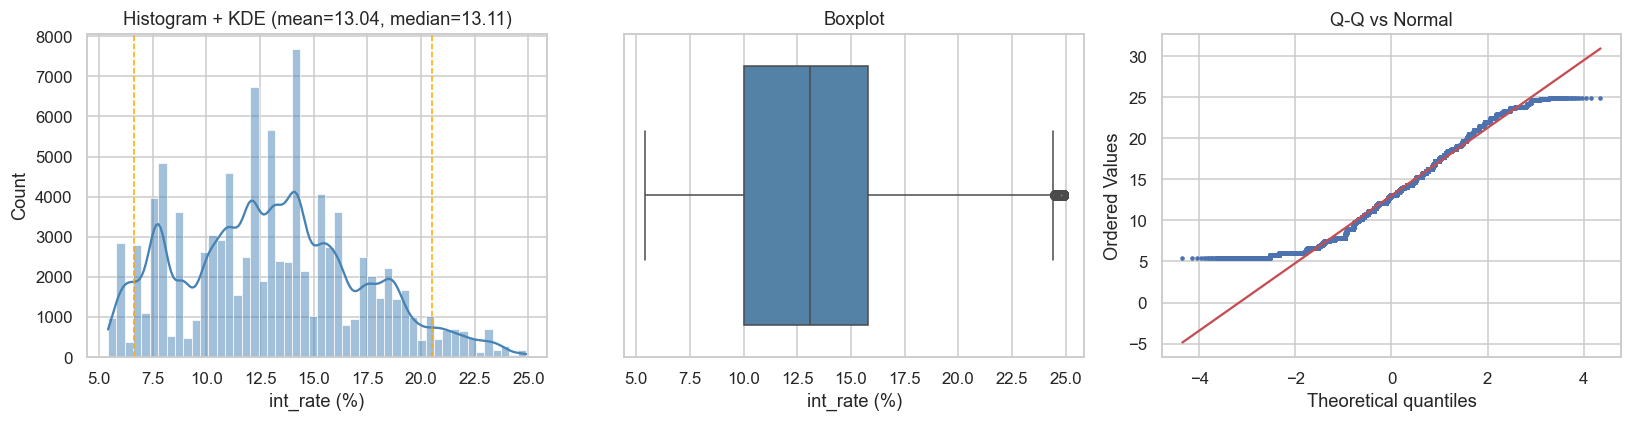

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram + KDE
sns.histplot(y, bins=50, kde=True, ax=axes[0], color="steelblue")
for q, c in zip([0.05, 0.95], ["orange", "orange"]):
    axes[0].axvline(y.quantile(q), color=c, linestyle="--", linewidth=1)
axes[0].set_title(f"Histogram + KDE (mean={y.mean():.2f}, median={y.median():.2f})")
axes[0].set_xlabel("int_rate (%)")

# Boxplot
sns.boxplot(x=y, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot")
axes[1].set_xlabel("int_rate (%)")

# Q-Q vs normal
stats.probplot(y, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q vs Normal")
axes[2].get_lines()[0].set_markersize(2)

save_fig("02_target_distribution")
plt.show()

In [8]:
# Quick verdict on whether a transform helps
def report_skew(name, vals):
    print(f"  {name:<15s} skew={stats.skew(vals):+.4f}  kurt={stats.kurtosis(vals):+.4f}")

print("Skew before / after candidate transforms:")
report_skew("identity",  y.values)
report_skew("log1p",     np.log1p(y.values))
report_skew("sqrt",      np.sqrt(y.values))
bc, lam = stats.boxcox(y.values + 1e-6)
report_skew(f"box-cox(λ={lam:.2f})", bc)

Skew before / after candidate transforms:
  identity        skew=+0.2884  kurt=-0.4466
  log1p           skew=-0.3384  kurt=-0.5644
  sqrt            skew=-0.0541  kurt=-0.6191


  box-cox(λ=0.52) skew=-0.0389  kurt=-0.6172


## 3. Missingness analysis

Two questions: (a) which columns are missing how much, and (b) what's the mechanism? If missingness clusters by `issue_d`, that's MNAR-structural (LC introduced the column later) — different remediation than MCAR/MAR.

In [9]:
null_counts = train.isna().sum().sort_values(ascending=False)
null_pct = (null_counts / len(train) * 100).round(2)
null_table = pd.DataFrame({"n_missing": null_counts, "pct": null_pct})
null_table = null_table[null_table["n_missing"] > 0]
print(f"Columns with any missingness: {len(null_table)}")
display(null_table.head(20))

Columns with any missingness: 23


,n_missing,pct
mo_sin_old_rev_tl_op,70277,70.28
num_accts_ever_120_pd,70276,70.28
mo_sin_rcnt_tl,70276,70.28
num_tl_90g_dpd_24m,70276,70.28
pct_tl_nvr_dlq,70276,70.28
percent_bc_gt_75,50584,50.58
mort_acc,50030,50.03
total_bc_limit,50030,50.03
emp_title,5984,5.98
emp_length,3150,3.15


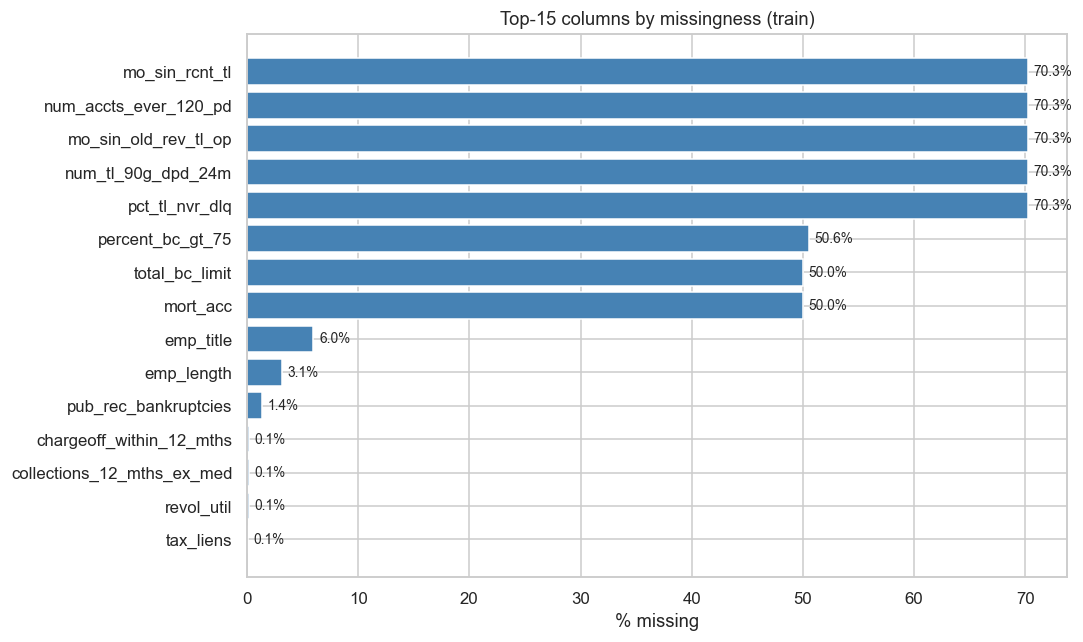

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
top15 = null_table.head(15).sort_values("pct")
ax.barh(top15.index, top15["pct"], color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Top-15 columns by missingness (train)")
for i, (col, pct) in enumerate(zip(top15.index, top15["pct"])):
    ax.text(pct + 0.5, i, f"{pct:.1f}%", va="center", fontsize=9)
save_fig("03_missingness_top15")
plt.show()

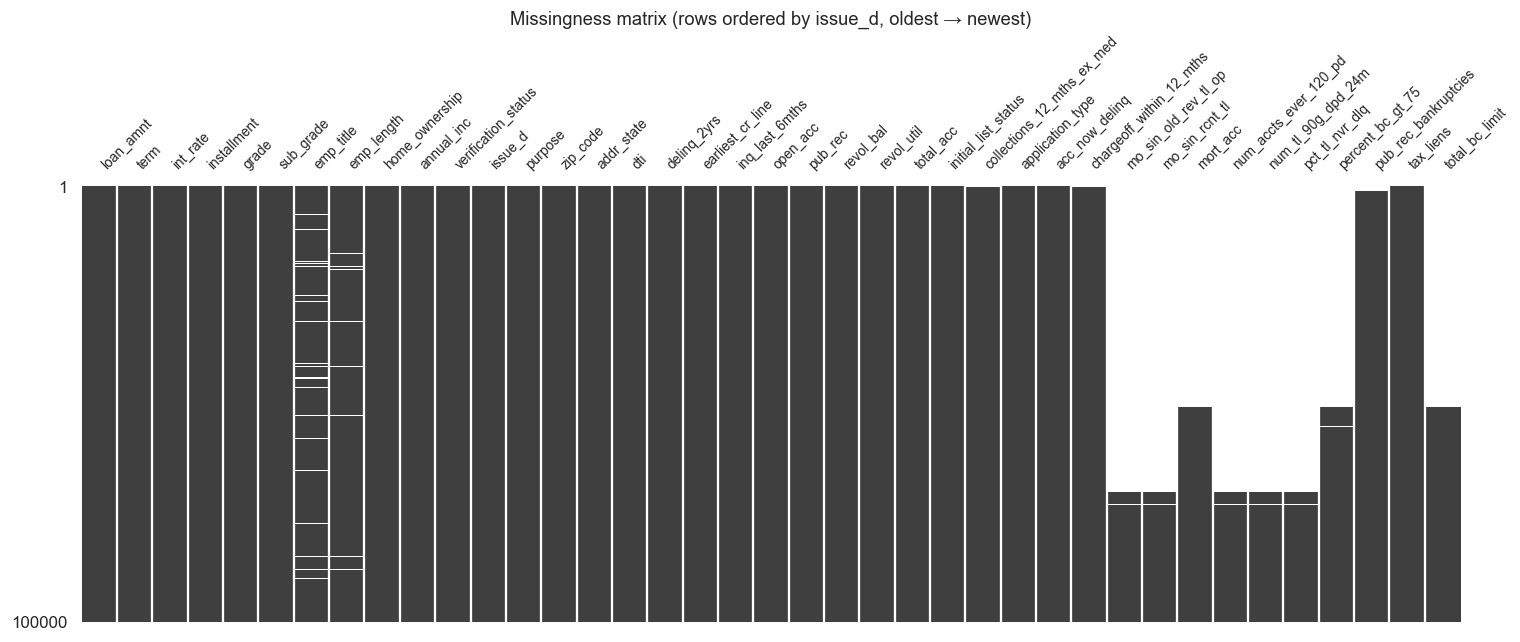

In [11]:
# Missingness matrix sorted by issue_d — visualizes temporal structure
train_sorted = train.sort_values("issue_d").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(train_sorted, sparkline=False, ax=ax, fontsize=9)
ax.set_title("Missingness matrix (rows ordered by issue_d, oldest → newest)")
save_fig("03_missingness_matrix")
plt.show()

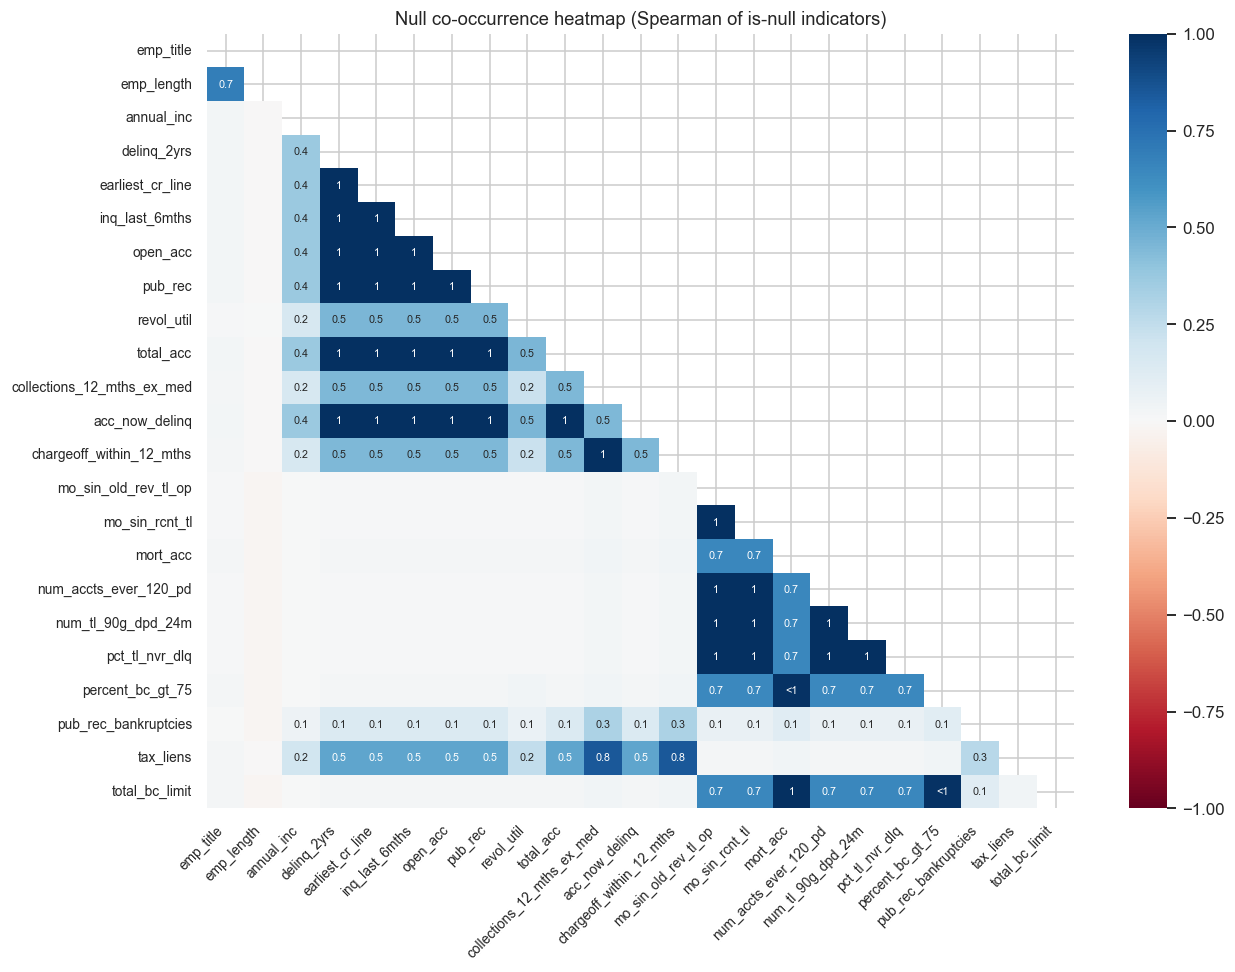

In [12]:
# Null co-occurrence heatmap
fig, ax = plt.subplots(figsize=(12, 9))
msno.heatmap(train, ax=ax, fontsize=9)
ax.set_title("Null co-occurrence heatmap (Spearman of is-null indicators)")
save_fig("03_missingness_cooccurrence")
plt.show()

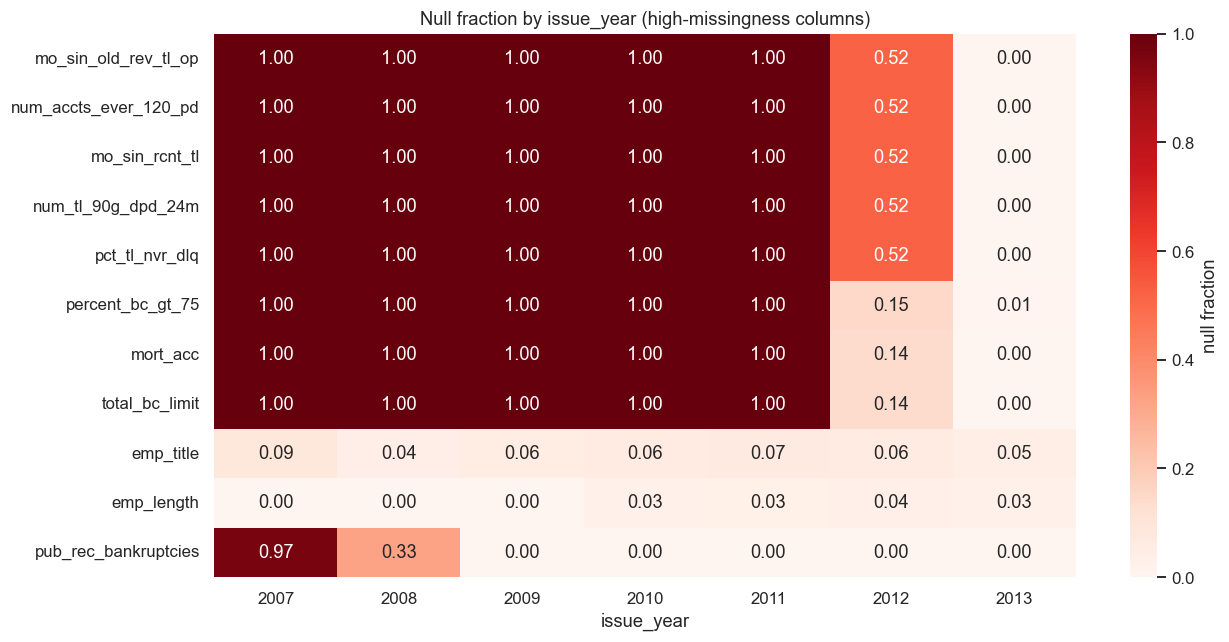

In [13]:
# Null fraction by year — exposes structural MNAR (column introduced mid-period)
train_sorted["issue_year"] = train_sorted["issue_d"].dt.year
high_miss_cols = null_table[null_table["pct"] > 1].index.tolist()
null_by_year = train_sorted.groupby("issue_year")[high_miss_cols].apply(
    lambda g: g.isna().mean()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(null_by_year.T, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "null fraction"}, ax=ax)
ax.set_title("Null fraction by issue_year (high-missingness columns)")
ax.set_xlabel("issue_year")
save_fig("03_missingness_by_year")
plt.show()

In [14]:
# Point-biserial: does missingness in column X correlate with int_rate?
pb_rows = []
for col in null_table.index:
    is_null = train[col].isna().astype(int)
    if is_null.sum() < 50 or is_null.sum() > len(train) - 50:
        continue
    r, p = stats.pointbiserialr(is_null, train["int_rate"])
    pb_rows.append({"column": col, "pct_missing": null_table.loc[col, "pct"],
                    "pointbiserial_r": r, "p_value": p})
pb_df = pd.DataFrame(pb_rows).sort_values("pointbiserial_r", key=abs, ascending=False)
print("Point-biserial correlation of missingness indicator with int_rate:")
display(pb_df.head(15).round(4))

Point-biserial correlation of missingness indicator with int_rate:


,column,pct_missing,pointbiserial_r,p_value
6,mort_acc,50.03,-0.1995,0.0
7,total_bc_limit,50.03,-0.1995,0.0
5,percent_bc_gt_75,50.58,-0.1970,0.0
4,pct_tl_nvr_dlq,70.28,-0.1718,0.0
2,mo_sin_rcnt_tl,70.28,-0.1718,0.0
3,num_tl_90g_dpd_24m,70.28,-0.1718,0.0
1,num_accts_ever_120_pd,70.28,-0.1718,0.0
0,mo_sin_old_rev_tl_op,70.28,-0.1718,0.0
8,emp_title,5.98,-0.0377,0.0
9,emp_length,3.15,-0.0342,0.0


## 4. Univariate distributions

Distribution shape for every numeric column (find skewed monetary fields and zero-inflated counters), and value counts for every categorical (find rare-level columns and the `emp_length` text encoding).

In [15]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "int_rate"]
print(f"{len(numeric_cols)} numeric columns to plot")

skew_table = pd.DataFrame({
    "skew":      [train[c].skew() for c in numeric_cols],
    "n_unique":  [train[c].nunique() for c in numeric_cols],
    "n_zero":    [(train[c] == 0).sum() for c in numeric_cols],
    "pct_zero":  [(train[c] == 0).mean() * 100 for c in numeric_cols],
}, index=numeric_cols).round(3)
skew_table = skew_table.sort_values("skew", key=abs, ascending=False)
print("Skewness ranking (by |skew|):")
display(skew_table.head(20))

24 numeric columns to plot
Skewness ranking (by |skew|):


,skew,n_unique,n_zero,pct_zero
acc_now_delinq,103.990,4,99945,99.945
collections_12_mths_ex_med,61.653,3,99825,99.825
tax_liens,49.701,6,99800,99.800
chargeoff_within_12_mths,40.299,4,99765,99.765
annual_inc,37.321,9893,0,0.000
revol_bal,11.171,34798,1394,1.394
num_tl_90g_dpd_24m,10.289,12,28397,28.397
pub_rec,5.726,6,95548,95.548
delinq_2yrs,5.720,16,87383,87.383
pub_rec_bankruptcies,5.479,6,95035,95.035


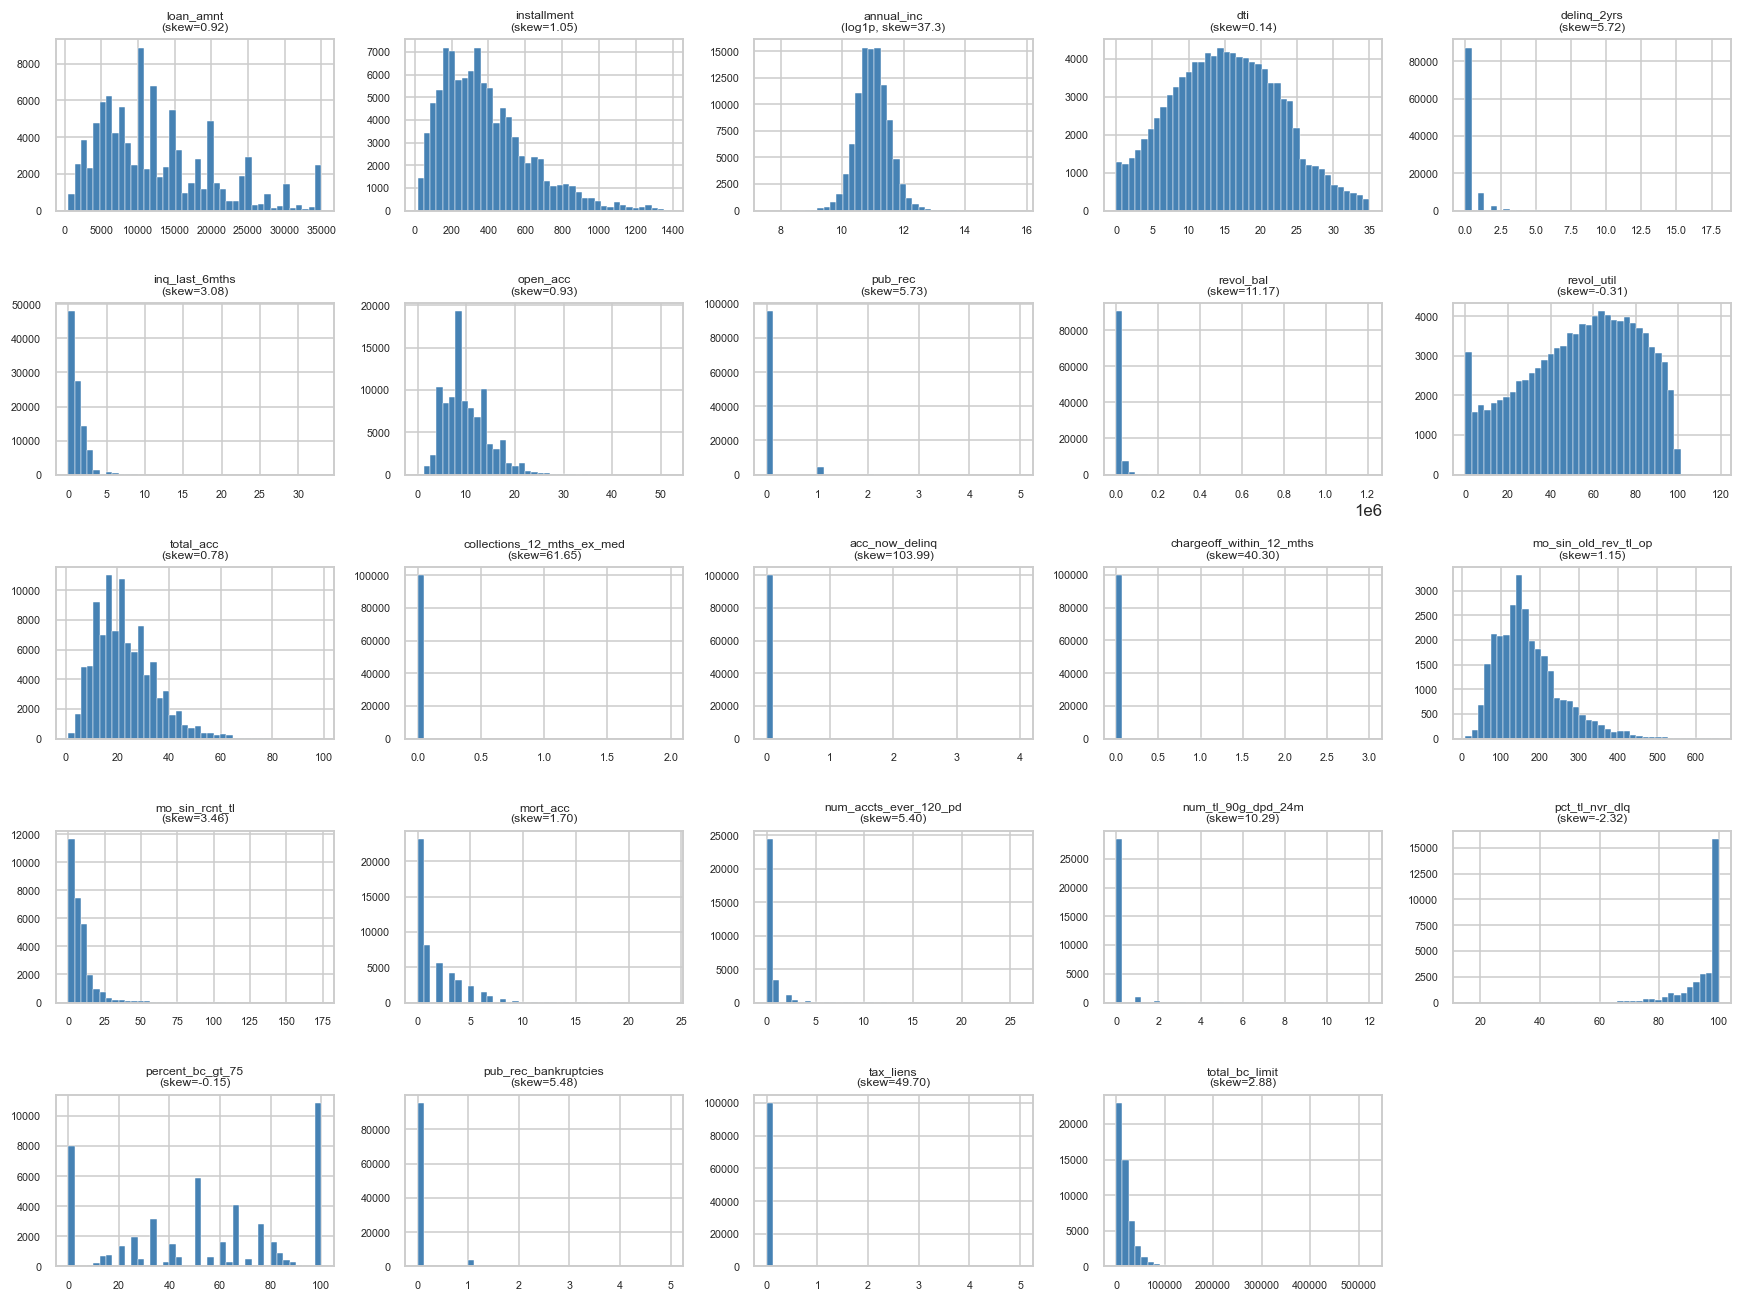

In [16]:
# 5×5 grid of numeric histograms — log scale where skew > 3
ncols, nrows = 5, int(np.ceil(len(numeric_cols) / 5))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.4))
for i, col in enumerate(numeric_cols):
    ax = axes.flat[i]
    series = train[col].dropna()
    log_scale = abs(series.skew()) > 3 and (series > 0).all()
    if log_scale:
        ax.hist(np.log1p(series), bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_title(f"{col}\n(log1p, skew={series.skew():.1f})", fontsize=8)
    else:
        ax.hist(series, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_title(f"{col}\n(skew={series.skew():.2f})", fontsize=8)
    ax.tick_params(labelsize=7)
for j in range(len(numeric_cols), nrows * ncols):
    axes.flat[j].axis("off")
save_fig("04_numeric_histograms")
plt.show()

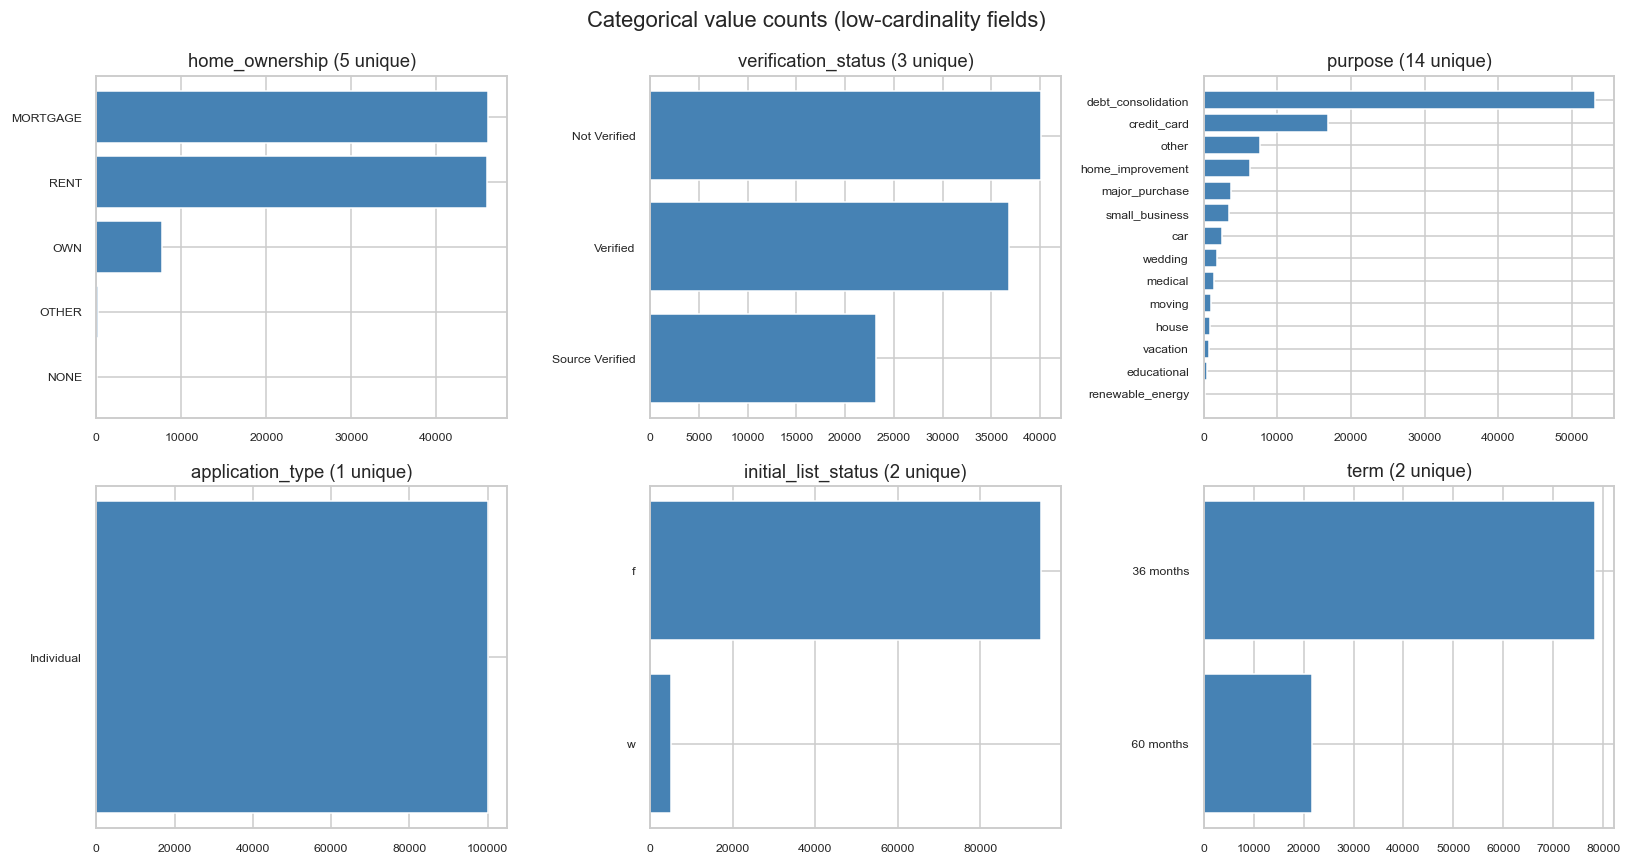

In [17]:
# Categorical value-count bars
cat_cols = [c for c in ["home_ownership", "verification_status", "purpose",
                        "application_type", "initial_list_status", "term"]
            if c in train.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    vc = train[col].value_counts(dropna=False).head(15)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color="steelblue")
    ax.set_title(f"{col} ({train[col].nunique(dropna=False)} unique)")
    ax.tick_params(labelsize=8)
plt.suptitle("Categorical value counts (low-cardinality fields)")
save_fig("04_categorical_counts")
plt.show()

In [18]:
# emp_length raw values + ordinal mapping proposal
emp_vc = train["emp_length"].value_counts(dropna=False)
print("emp_length raw value counts:")
print(emp_vc.to_string())
print("\nProposed ordinal mapping (from src/archive/preprocessing_and_modeling.py):")
for k, v in EMP_LENGTH_MAP.items():
    print(f"  {k:<12s} → {v}")

emp_length raw value counts:
emp_length
10+ years    26103
2 years       9987
< 1 year      9442
3 years       8555
5 years       8324
4 years       7853
1 year        7477
6 years       6407
7 years       5192
8 years       4101
9 years       3409
NaN           3150

Proposed ordinal mapping (from src/archive/preprocessing_and_modeling.py):
  < 1 year     → 0
  1 year       → 1
  2 years      → 2
  3 years      → 3
  4 years      → 4
  5 years      → 5
  6 years      → 6
  7 years      → 7
  8 years      → 8
  9 years      → 9
  10+ years    → 10
  n/a          → None


## 5. Temporal analysis

The macro story dominates everything else. LC's loan volume exploded between 2007 and 2013, and the mean rate drifted upward as the platform matured and credit conditions evolved. Any feature that trends with time is partially confounded with this macro drift — temporal validation will discount its apparent power.

In [19]:
# Build issue_year / issue_quarter (EDA-only; do NOT persist as model features
# — FINDINGS.md note 6 shows year is out-of-distribution in val and trees can't extrapolate)
train["issue_year"] = train["issue_d"].dt.year
train["issue_quarter"] = train["issue_d"].dt.to_period("Q").astype(str)
test["issue_year"] = test["issue_d"].dt.year
test["issue_quarter"] = test["issue_d"].dt.to_period("Q").astype(str)

print("Loan counts by year:")
display(pd.concat([
    train["issue_year"].value_counts().sort_index().rename("train"),
    test["issue_year"].value_counts().sort_index().rename("test"),
], axis=1).fillna(0).astype(int))

Loan counts by year:


,train,test
issue_year,,
2007,603,0
2008,2393,0
2009,5281,0
2010,12537,0
2011,21721,0
2012,53367,0
2013,4098,10000


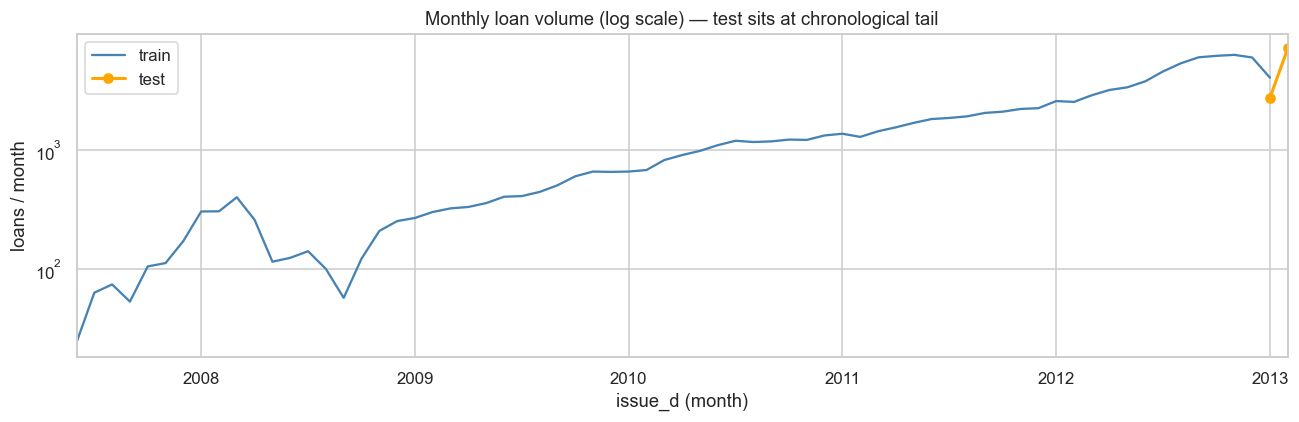

In [20]:
# Volume drift: monthly counts, train + test on same axis
train_monthly = train.groupby(train["issue_d"].dt.to_period("M").dt.to_timestamp()).size().rename("train")
test_monthly  = test.groupby(test["issue_d"].dt.to_period("M").dt.to_timestamp()).size().rename("test")

fig, ax = plt.subplots(figsize=(12, 4))
train_monthly.plot(ax=ax, label="train", color="steelblue", linewidth=1.5)
test_monthly.plot(ax=ax, label="test", color="orange", linewidth=2, marker="o")
ax.set_yscale("log")
ax.set_title("Monthly loan volume (log scale) — test sits at chronological tail")
ax.set_ylabel("loans / month")
ax.set_xlabel("issue_d (month)")
ax.legend()
save_fig("05_volume_drift")
plt.show()

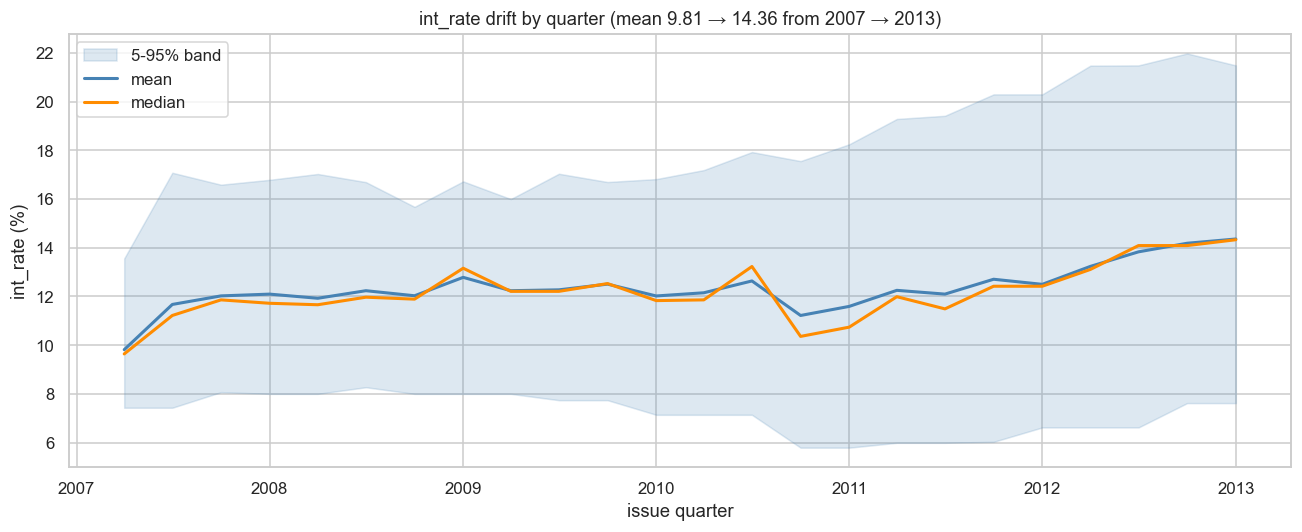

First quarter mean: 9.81
Last  quarter mean: 14.36


In [21]:
# Target drift: mean int_rate by quarter with 5/95 band
quarterly = train.groupby(train["issue_d"].dt.to_period("Q").dt.to_timestamp())["int_rate"].agg(
    ["mean", "median", lambda s: s.quantile(0.05), lambda s: s.quantile(0.95), "count"]
)
quarterly.columns = ["mean", "median", "p05", "p95", "n"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(quarterly.index, quarterly["p05"], quarterly["p95"],
                alpha=0.18, color="steelblue", label="5-95% band")
ax.plot(quarterly.index, quarterly["mean"], color="steelblue", linewidth=2, label="mean")
ax.plot(quarterly.index, quarterly["median"], color="darkorange", linewidth=2, label="median")
ax.set_title(
    f"int_rate drift by quarter (mean {quarterly['mean'].iloc[0]:.2f} → "
    f"{quarterly['mean'].iloc[-1]:.2f} from 2007 → 2013)"
)
ax.set_ylabel("int_rate (%)")
ax.set_xlabel("issue quarter")
ax.legend()
save_fig("05_target_drift")
plt.show()
print(f"First quarter mean: {quarterly['mean'].iloc[0]:.2f}")
print(f"Last  quarter mean: {quarterly['mean'].iloc[-1]:.2f}")

Mean of key features by issue_year:


,loan_amnt,annual_inc,dti,revol_util,mort_acc,total_bc_limit,percent_bc_gt_75
issue_year,,,,,,,
2007,8254.52,64742.25,10.71,47.17,NaN,NaN,NaN
2008,8825.43,65241.74,13.20,48.91,NaN,NaN,NaN
2009,9833.03,69192.29,12.47,45.72,NaN,NaN,NaN
2010,10528.24,69512.99,13.10,48.60,NaN,NaN,NaN
2011,12047.50,69456.01,13.85,50.31,NaN,NaN,NaN
2012,13461.71,69720.23,16.66,57.90,1.61,19609.34,53.34
2013,15194.65,73432.48,17.44,62.59,1.76,20444.58,58.97


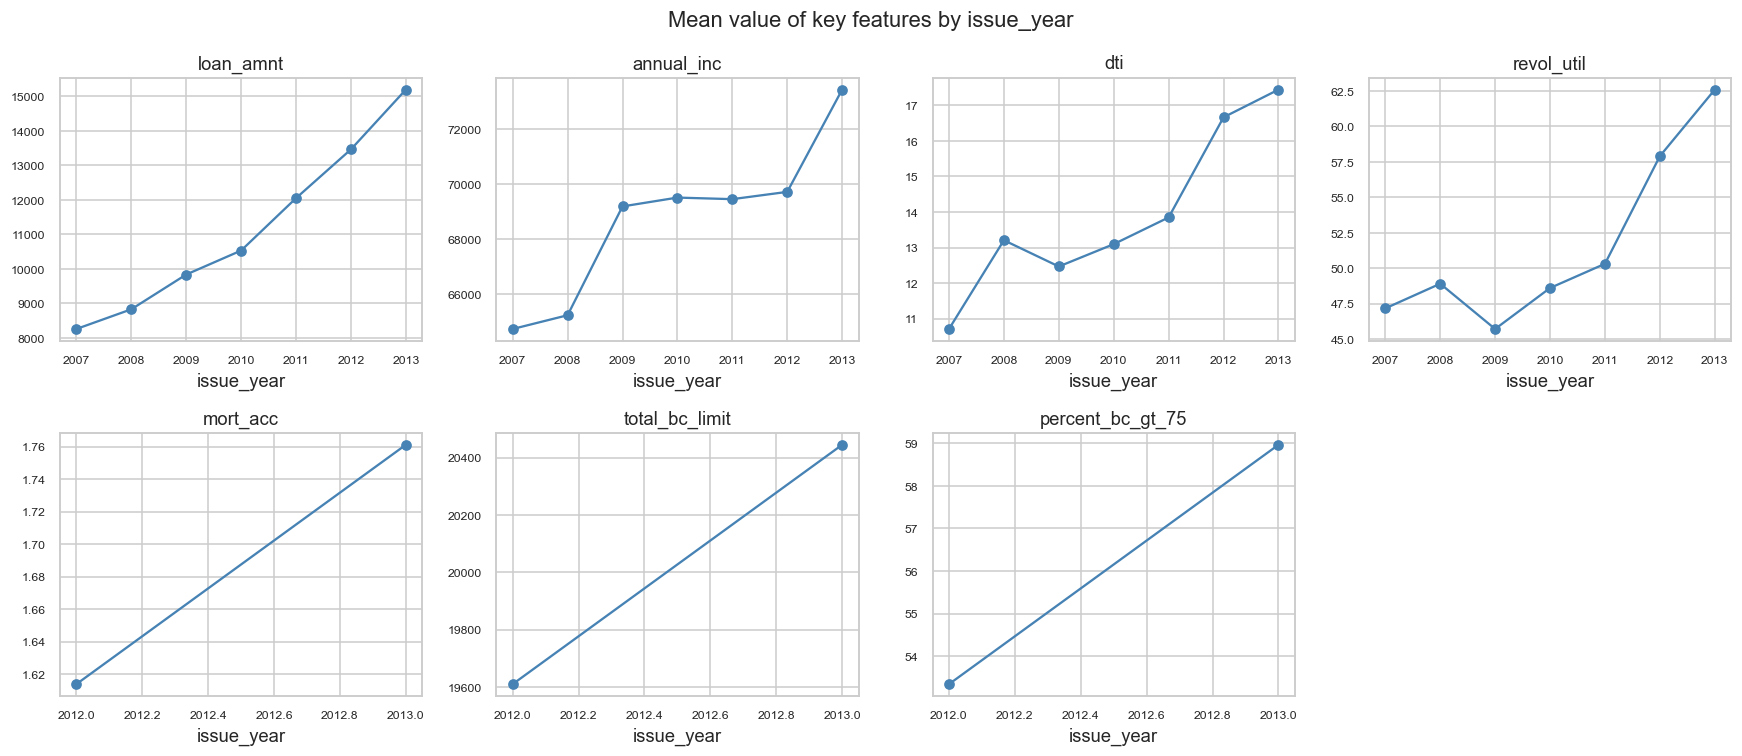

In [22]:
# Key feature drift: how much do core features trend with time?
drift_cols = ["loan_amnt", "annual_inc", "dti", "revol_util", "mort_acc",
              "total_bc_limit", "percent_bc_gt_75"]
drift_cols = [c for c in drift_cols if c in train.columns]

drift_means = train.groupby("issue_year")[drift_cols].mean()
print("Mean of key features by issue_year:")
display(drift_means.round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, drift_cols):
    train.groupby("issue_year")[col].mean().plot(ax=ax, marker="o", color="steelblue")
    ax.set_title(col)
    ax.tick_params(labelsize=8)
for j in range(len(drift_cols), 8):
    axes.flat[j].axis("off")
plt.suptitle("Mean value of key features by issue_year")
save_fig("05_feature_drift")
plt.show()

## 6. Bivariate analysis vs target

Spearman correlation handles the skew in monetary columns better than Pearson. The categorical boxplots and the `addr_state` bar chart probe what each non-numeric column buys you.

In [23]:
# Pearson + Spearman ranking — exclude the known leakage cols from the rank
features_for_corr = [c for c in numeric_cols
                     if c not in {"int_rate", "ID", "issue_year"} and c not in LEAKAGE_COLS]
rows = []
for c in features_for_corr:
    valid = train[[c, "int_rate"]].dropna()
    if len(valid) < 100:
        continue
    pr, _ = stats.pearsonr(valid[c], valid["int_rate"])
    sr, _ = stats.spearmanr(valid[c], valid["int_rate"])
    rows.append({"feature": c, "pearson": pr, "spearman": sr, "n": len(valid)})
corr_df = pd.DataFrame(rows).set_index("feature")
corr_df["abs_spearman"] = corr_df["spearman"].abs()
corr_df = corr_df.sort_values("abs_spearman", ascending=False)
print("Top 15 features by |Spearman| with int_rate:")
display(corr_df.head(15).round(4))

Top 15 features by |Spearman| with int_rate:


,pearson,spearman,n,abs_spearman
feature,,,,
revol_util,0.4659,0.4676,99862,0.4676
percent_bc_gt_75,0.4096,0.4021,49416,0.4021
loan_amnt,0.3396,0.2866,100000,0.2866
inq_last_6mths,0.1567,0.2096,99971,0.2096
pct_tl_nvr_dlq,-0.1830,-0.2088,29724,0.2088
total_bc_limit,-0.1827,-0.1718,49970,0.1718
dti,0.1747,0.1704,100000,0.1704
revol_bal,0.0895,0.1688,100000,0.1688
delinq_2yrs,0.1436,0.1592,99971,0.1592


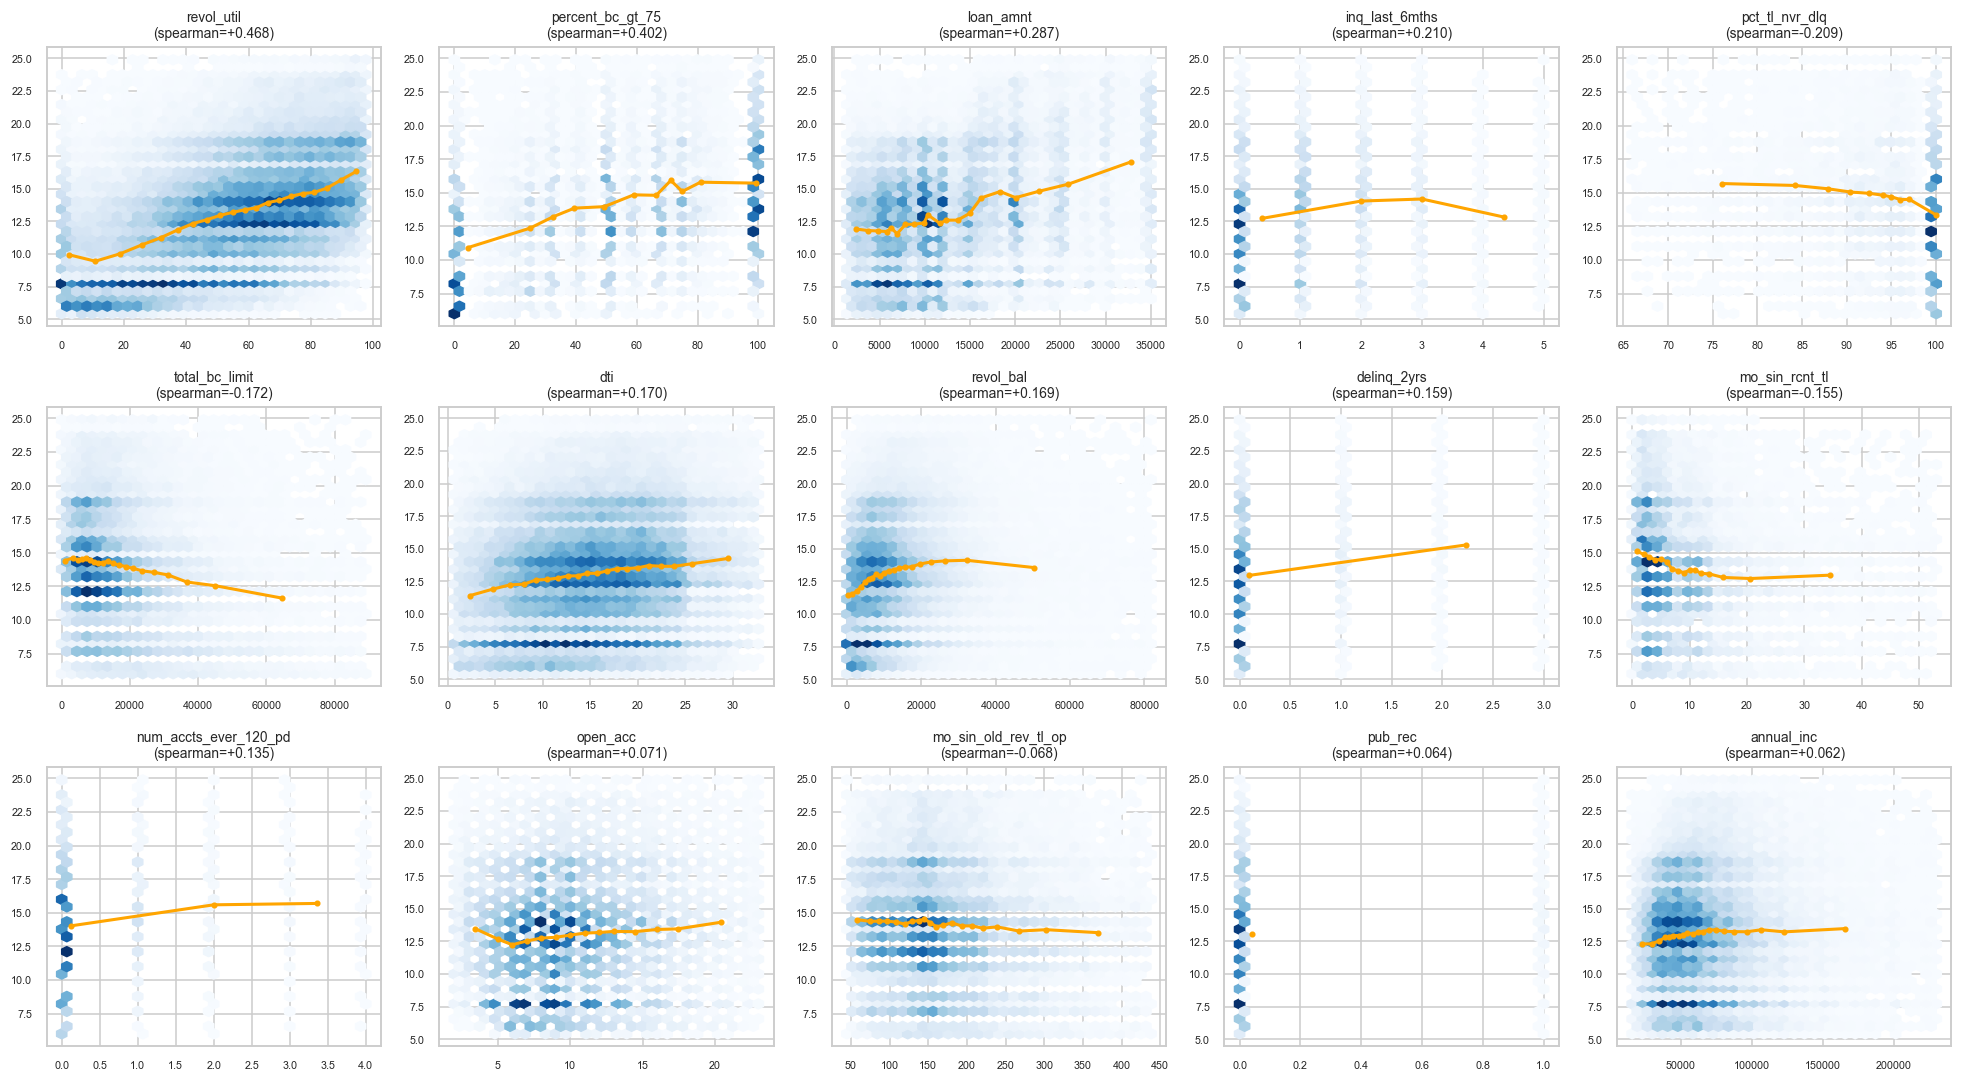

In [24]:
# Hexbin grid for top-15 most-correlated numerics
top15_feats = corr_df.head(15).index.tolist()
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.flat, top15_feats):
    sub = train[[col, "int_rate"]].dropna()
    # cap extreme tails for visibility (1st-99th pctile)
    lo, hi = sub[col].quantile([0.01, 0.99])
    sub = sub[(sub[col] >= lo) & (sub[col] <= hi)]
    hb = ax.hexbin(sub[col], sub["int_rate"], gridsize=30, cmap="Blues", mincnt=1)
    # binned mean overlay
    bins = pd.qcut(sub[col], q=20, duplicates="drop")
    binned = sub.groupby(bins, observed=True).agg({col: "mean", "int_rate": "mean"})
    ax.plot(binned[col], binned["int_rate"], color="orange", linewidth=2, marker="o", markersize=3)
    sp = corr_df.loc[col, "spearman"]
    ax.set_title(f"{col}\n(spearman={sp:+.3f})", fontsize=9)
    ax.tick_params(labelsize=7)
save_fig("06_bivariate_hexbin")
plt.show()

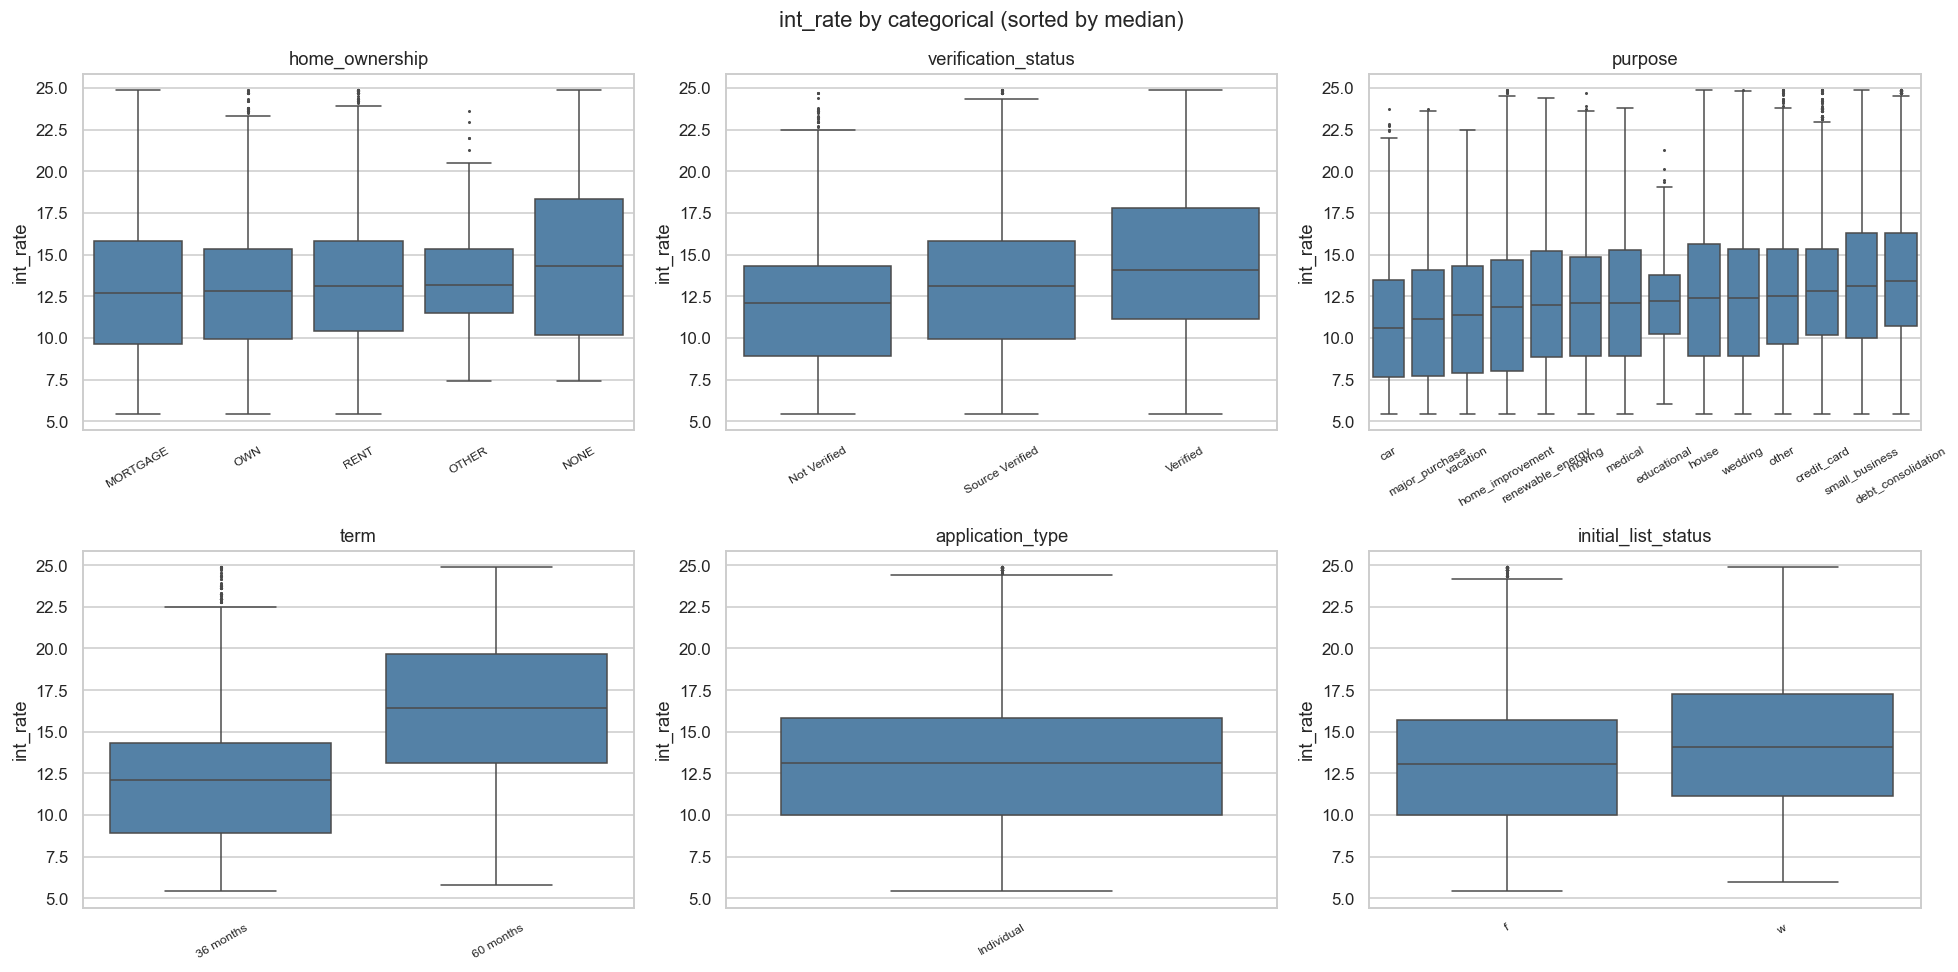

In [25]:
# Categorical boxplots vs target
cat_for_box = ["home_ownership", "verification_status", "purpose", "term",
               "application_type", "initial_list_status"]
cat_for_box = [c for c in cat_for_box if c in train.columns]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, cat_for_box):
    order = train.groupby(col)["int_rate"].median().sort_values().index
    sns.boxplot(data=train, x=col, y="int_rate", order=order, ax=ax, color="steelblue", fliersize=1)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.set_xlabel("")
plt.suptitle("int_rate by categorical (sorted by median)")
save_fig("06_categorical_boxplots")
plt.show()

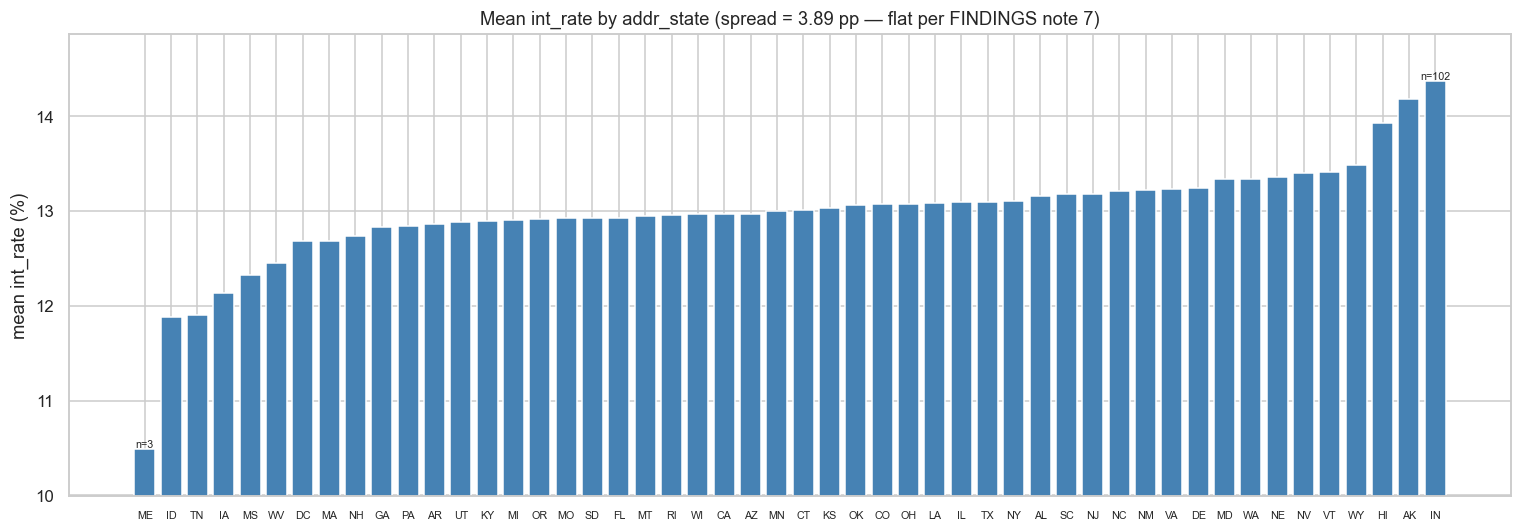

In [26]:
# addr_state sorted bar with sample-size annotations
state_stats = train.groupby("addr_state")["int_rate"].agg(["mean", "count"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(state_stats.index, state_stats["mean"], color="steelblue")
ax.set_title(
    f"Mean int_rate by addr_state "
    f"(spread = {state_stats['mean'].max() - state_stats['mean'].min():.2f} pp — flat per FINDINGS note 7)"
)
ax.set_ylabel("mean int_rate (%)")
ax.tick_params(axis="x", labelsize=7)
ax.set_ylim(state_stats["mean"].min() - 0.5, state_stats["mean"].max() + 0.5)
# Annotate the extremes
for i in [0, -1]:
    ax.text(i % len(state_stats), state_stats["mean"].iloc[i], f"n={state_stats['count'].iloc[i]}",
            ha="center", va="bottom", fontsize=7)
save_fig("06_state_bar")
plt.show()

## 7. Correlation & multicollinearity

Pairwise feature correlations expose redundancy clusters. Pairs with |r|>0.85 are candidates for dropping the less interpretable / sparser member of the pair before modeling — XGBoost is robust to multicollinearity for predictive accuracy but the SHAP attributions split across correlated features in confusing ways.

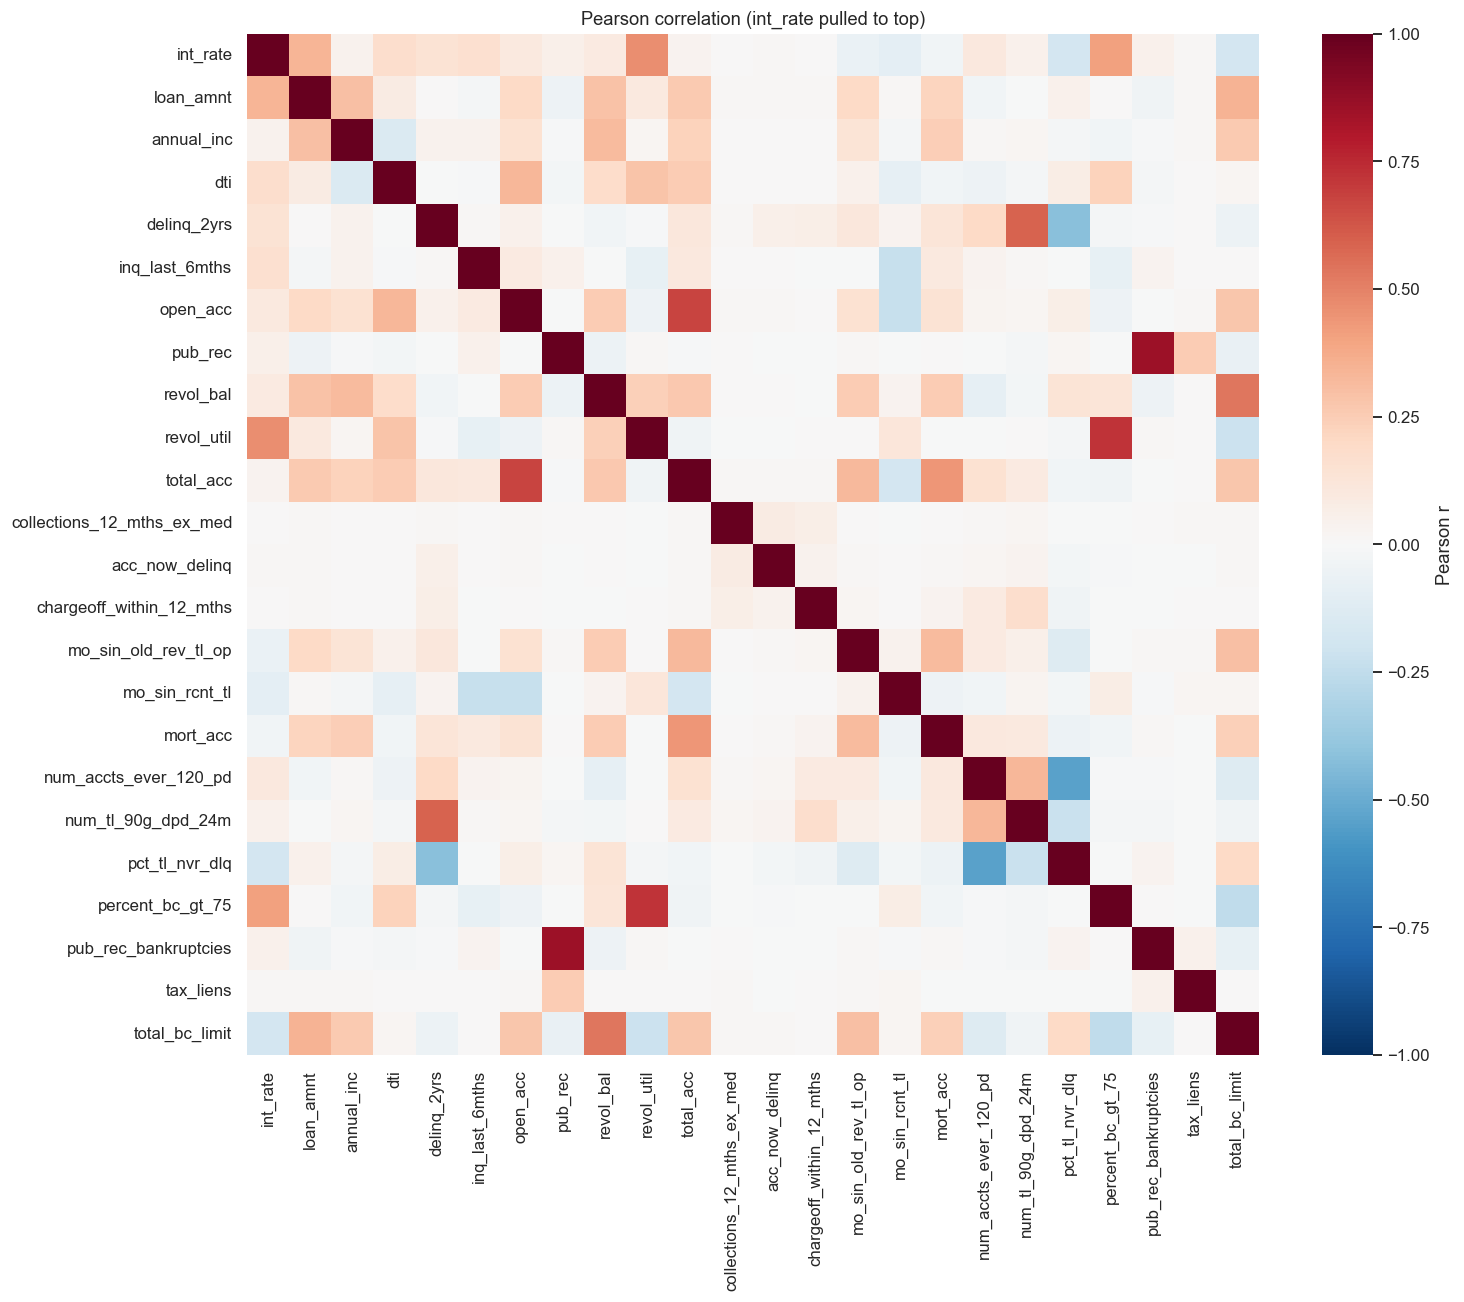

In [27]:
# Numeric correlation heatmap (excluding leakage cols)
corr_cols = [c for c in numeric_cols
             if c not in {"ID", "issue_year"} and c not in LEAKAGE_COLS]
corr_mat = train[corr_cols + ["int_rate"]].corr()
# Pull int_rate row/col to top for readability
order = ["int_rate"] + [c for c in corr_mat.columns if c != "int_rate"]
corr_mat = corr_mat.loc[order, order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pearson correlation (int_rate pulled to top)")
save_fig("07_correlation_heatmap")
plt.show()

In [28]:
# High-correlation pairs (|r|>0.7) excluding self-pairs and int_rate
pair_corr = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)).stack()
pair_corr = pair_corr[pair_corr.abs() > 0.7]
pair_corr = pair_corr.sort_values(key=abs, ascending=False)
pair_df = pair_corr.reset_index()
pair_df.columns = ["feature_a", "feature_b", "pearson_r"]
pair_df = pair_df[~pair_df.apply(lambda r: r["feature_a"] == "int_rate" or r["feature_b"] == "int_rate", axis=1)]
print(f"Numeric pairs with |Pearson r| > 0.7: {len(pair_df)}")
display(pair_df.round(4))

Numeric pairs with |Pearson r| > 0.7: 2


,feature_a,feature_b,pearson_r
0,pub_rec,pub_rec_bankruptcies,0.8575
1,revol_util,percent_bc_gt_75,0.7264


## 8. Leakage audit

Three columns must be dropped before training: `grade`, `sub_grade`, `installment`.

- `grade` and `sub_grade` are LC's internal risk grades, **derived from** the model that sets the rate. Correlation with `int_rate` should be ≈ 0.92 and ≈ 0.94 respectively.
- `installment` looks innocent (marginal correlation ≈ 0.34), but it is the **PMT formula** applied to (`loan_amnt`, `term`, `int_rate`). Conditional on `loan_amnt` and `term`, knowing `installment` exactly determines `int_rate`. Partial correlation ≈ 0.9998.

This section produces the evidence.

In [29]:
grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
sub_grade_map = {f"{g}{n}": i * 5 + n
                 for i, g in enumerate("ABCDEFG") for n in range(1, 6)}

audit_df = train.assign(
    grade_num=train["grade"].map(grade_map),
    sub_grade_num=train["sub_grade"].map(sub_grade_map),
)
print(f"corr(grade,      int_rate) = {audit_df['grade_num'].corr(audit_df['int_rate']):.4f}")
print(f"corr(sub_grade,  int_rate) = {audit_df['sub_grade_num'].corr(audit_df['int_rate']):.4f}")
print(f"corr(installment, int_rate) (marginal, MISLEADING) = "
      f"{audit_df['installment'].corr(audit_df['int_rate']):.4f}")

corr(grade,      int_rate) = 0.9222
corr(sub_grade,  int_rate) = 0.9389
corr(installment, int_rate) (marginal, MISLEADING) = 0.3365


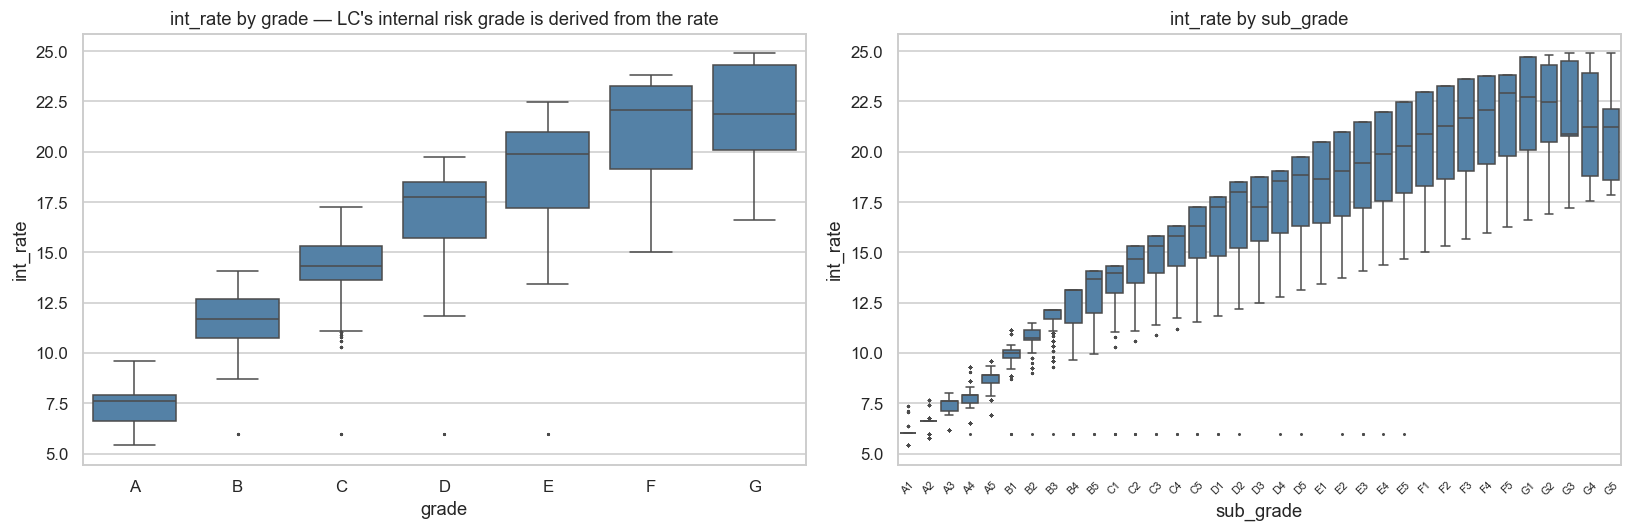

In [30]:
# Boxplot of int_rate by grade — visually catastrophic separation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=train, x="grade", y="int_rate", order=sorted(train["grade"].dropna().unique()),
            ax=axes[0], color="steelblue", fliersize=1)
axes[0].set_title("int_rate by grade — LC's internal risk grade is derived from the rate")

sub_order = sorted(train["sub_grade"].dropna().unique())
sns.boxplot(data=train, x="sub_grade", y="int_rate", order=sub_order,
            ax=axes[1], color="steelblue", fliersize=1)
axes[1].set_title("int_rate by sub_grade")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
save_fig("08_grade_separation")
plt.show()

In [31]:
# The PMT-derivation demo: installment = PMT(loan_amnt, term_months, monthly_rate)
# PMT = (r * P) / (1 - (1 + r) ** -n), where r = (int_rate/100)/12 and n = term in months.
term_months = train["term"].str.extract(r"(\d+)").astype(float).iloc[:, 0]
P = train["loan_amnt"]
r = (train["int_rate"] / 100.0) / 12.0
n = term_months
installment_implied = (r * P) / (1.0 - (1.0 + r) ** (-n))

valid = installment_implied.notna() & train["installment"].notna()
implied_corr = installment_implied[valid].corr(train.loc[valid, "installment"])
abs_err = (installment_implied[valid] - train.loc[valid, "installment"]).abs()
print(f"corr(installment_implied, installment_actual) = {implied_corr:.6f}")
print(f"mean |implied - actual| = ${abs_err.mean():.4f}")
print(f"max  |implied - actual| = ${abs_err.max():.4f}")
print()
print("Interpretation: `installment` is algebraically `int_rate` given `loan_amnt` and `term`.")

corr(installment_implied, installment_actual) = 0.993982
mean |implied - actual| = $3.1987
max  |implied - actual| = $745.7214

Interpretation: `installment` is algebraically `int_rate` given `loan_amnt` and `term`.


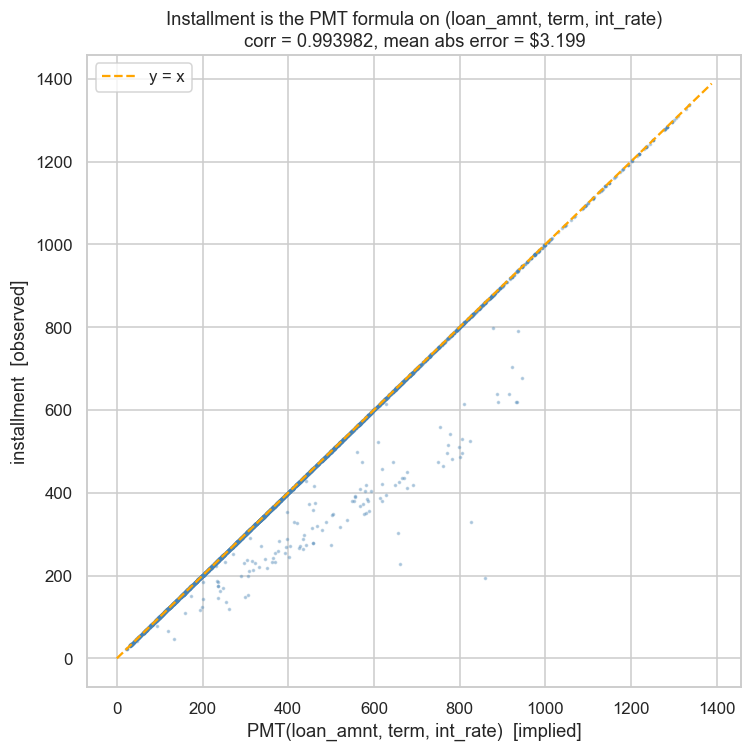

In [32]:
# Visualize: scatter of implied vs actual installment
fig, ax = plt.subplots(figsize=(7, 7))
sample_idx = np.random.choice(valid[valid].index, size=5000, replace=False)
ax.scatter(installment_implied.loc[sample_idx], train.loc[sample_idx, "installment"],
           s=2, alpha=0.3, color="steelblue")
mx = train["installment"].max()
ax.plot([0, mx], [0, mx], color="orange", linewidth=1.5, linestyle="--", label="y = x")
ax.set_xlabel("PMT(loan_amnt, term, int_rate)  [implied]")
ax.set_ylabel("installment  [observed]")
ax.set_title(f"Installment is the PMT formula on (loan_amnt, term, int_rate)\n"
             f"corr = {implied_corr:.6f}, mean abs error = ${abs_err.mean():.3f}")
ax.legend()
save_fig("08_installment_pmt")
plt.show()

In [33]:
# Partial correlation: corr(installment, int_rate) controlling for loan_amnt and term
# Method: regress each of installment & int_rate on (loan_amnt, term_months), correlate residuals
from numpy.linalg import lstsq

valid_idx = train["installment"].notna() & train["int_rate"].notna() & term_months.notna()
X = np.column_stack([np.ones(valid_idx.sum()),
                     train.loc[valid_idx, "loan_amnt"].values,
                     term_months[valid_idx].values])
y_inst = train.loc[valid_idx, "installment"].values
y_rate = train.loc[valid_idx, "int_rate"].values

beta_inst, *_ = lstsq(X, y_inst, rcond=None)
beta_rate, *_ = lstsq(X, y_rate, rcond=None)
resid_inst = y_inst - X @ beta_inst
resid_rate = y_rate - X @ beta_rate

partial_r = np.corrcoef(resid_inst, resid_rate)[0, 1]
print(f"Partial corr(installment, int_rate | loan_amnt, term) = {partial_r:.6f}")
print()
print(f"Compare to marginal corr = {audit_df['installment'].corr(audit_df['int_rate']):.4f}")
print("→ Marginal correlation is misleading. installment is leakage.")
print()
print(f"LEAKAGE_COLS to drop before modeling: {LEAKAGE_COLS}")

Partial corr(installment, int_rate | loan_amnt, term) = 0.491570

Compare to marginal corr = 0.3365
→ Marginal correlation is misleading. installment is leakage.

LEAKAGE_COLS to drop before modeling: ['grade', 'sub_grade', 'installment']


## 9. Cardinality analysis

High-cardinality string columns need an explicit encoding strategy. `emp_title` (~4k unique free text), `zip_code` (~673 masked prefixes), and `addr_state` (~50) each call for a different treatment.

In [34]:
card_rows = []
for c in train.columns:
    if c in ("int_rate", "issue_d", "issue_year", "issue_quarter"):
        continue
    nunique = train[c].nunique(dropna=True)
    n_missing = train[c].isna().sum()
    top = train[c].value_counts(dropna=True).head(3)
    top_str = ", ".join(f"{v}:{n}" for v, n in top.items())
    card_rows.append({
        "column": c,
        "dtype": str(train[c].dtype),
        "n_unique": nunique,
        "pct_missing": round(n_missing / len(train) * 100, 2),
        "top_3": top_str[:80],
    })
card_df = pd.DataFrame(card_rows).sort_values("n_unique", ascending=False)
print("Cardinality table (sorted by n_unique):")
display(card_df.head(20))

Cardinality table (sorted by n_unique):


,column,dtype,n_unique,pct_missing,top_3
5,emp_title,str,67679,5.98,"US Army:352, Bank of America:244, Kaiser Perma..."
19,revol_bal,float64,34798,0.00,"0.0:1394, 1.0:16, 255.0:15"
2,installment,float64,25705,0.00,"332.72:481, 337.47:395, 399.26:384"
8,annual_inc,float64,9893,0.00,"60000.0:3757, 50000.0:3201, 40000.0:2688"
36,total_bc_limit,float64,4467,50.03,"0.0:554, 5000.0:372, 4000.0:333"
13,dti,float64,3498,0.00,"0.0:244, 12.0:106, 19.2:99"
0,loan_amnt,float64,1154,0.00,"10000.0:7208, 12000.0:5769, 20000.0:4257"
20,revol_util,float64,1125,0.14,"0.0:1349, 66.8:161, 80.6:157"
11,zip_code,str,850,0.00,"112xx:1339, 100xx:1334, 945xx:1306"
15,earliest_cr_line,str,569,0.03,"Oct-2000:934, Oct-1999:865, Dec-1998:827"


In [35]:
recommendations = pd.DataFrame([
    ["emp_title",   "~4k unique free text",   "DROP — weak signal in FINDINGS, no clean grouping"],
    ["zip_code",    "~673 masked 3-digit",    "DROP — first-digit signal is 0.27pp (FINDINGS note 7)"],
    ["addr_state",  "~50 US states",          "KEEP — native XGBoost categorical (no target encoding)"],
    ["purpose",     "~14 levels",             "KEEP — native categorical, all levels frequent"],
    ["sub_grade",   "35 levels",              "DROP — leakage (Section 8)"],
    ["grade",       "7 levels",               "DROP — leakage (Section 8)"],
    ["emp_length",  "11 ordinal-like levels", "ENCODE — map via EMP_LENGTH_MAP to ordinal int"],
    ["home_ownership",      "5 levels", "KEEP — native categorical"],
    ["verification_status", "3 levels", "KEEP — native categorical"],
    ["term",                "2 levels", "EXTRACT — parse integer months"],
    ["application_type",    "1-2 lvls", "DROP if constant — confirm in train+test"],
    ["initial_list_status", "1-2 lvls", "KEEP — native categorical if non-constant"],
], columns=["column", "cardinality", "recommendation"])
display(recommendations)

,column,cardinality,recommendation
0,emp_title,~4k unique free text,"DROP — weak signal in FINDINGS, no clean grouping"
1,zip_code,~673 masked 3-digit,DROP — first-digit signal is 0.27pp (FINDINGS ...
2,addr_state,~50 US states,KEEP — native XGBoost categorical (no target e...
3,purpose,~14 levels,"KEEP — native categorical, all levels frequent"
4,sub_grade,35 levels,DROP — leakage (Section 8)
5,grade,7 levels,DROP — leakage (Section 8)
6,emp_length,11 ordinal-like levels,ENCODE — map via EMP_LENGTH_MAP to ordinal int
7,home_ownership,5 levels,KEEP — native categorical
8,verification_status,3 levels,KEEP — native categorical
9,term,2 levels,EXTRACT — parse integer months


## 10. Train vs test distribution parity (drift check)

Test is a chronologically-later slice, so feature drift is expected. We quantify it three ways: Kolmogorov-Smirnov test per numeric column, Population Stability Index (PSI, 10-bin), and chi-square per categorical. Drift here tells us which features will be hardest to generalize on, not whether the split is "broken."

In [36]:
# PSI helper
def psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return np.nan  # too-degenerate distribution for PSI
    edges[0], edges[-1] = -np.inf, np.inf
    e_pct = pd.cut(expected, edges).value_counts(normalize=True).sort_index()
    a_pct = pd.cut(actual, edges).value_counts(normalize=True).sort_index()
    eps = 1e-6
    return float(((a_pct - e_pct) * np.log((a_pct + eps) / (e_pct + eps))).sum())

drift_rows = []
shared_numeric = [c for c in numeric_cols if c in test.columns and c not in {"issue_year", "ID"}]
for c in shared_numeric:
    a, b = train[c].dropna(), test[c].dropna()
    if len(a) < 50 or len(b) < 50:
        continue
    ks_stat, ks_p = stats.ks_2samp(a, b)
    drift_rows.append({
        "feature": c,
        "ks_D": ks_stat,
        "ks_p": ks_p,
        "psi": psi(a, b),
        "train_mean": a.mean(),
        "test_mean":  b.mean(),
        "delta_mean": b.mean() - a.mean(),
    })
drift_df = pd.DataFrame(drift_rows).set_index("feature").sort_values("ks_D", ascending=False)
print("Numeric drift between train and test (sorted by KS D-statistic):")
display(drift_df.round(4).head(20))
print()
print("PSI interpretation: <0.1 = stable, 0.1-0.2 = monitor, >0.2 = significant shift")

Numeric drift between train and test (sorted by KS D-statistic):


,ks_D,ks_p,psi,train_mean,test_mean,delta_mean
feature,,,,,,
installment,0.2210,0.0000,0.2781,381.8418,491.4838,109.6420
loan_amnt,0.1850,0.0000,0.2121,12523.8005,15799.8175,3276.0170
revol_bal,0.1560,0.0000,0.2062,14866.9584,19092.0451,4225.0867
revol_util,0.1387,0.0000,0.1341,54.3594,62.2458,7.8864
open_acc,0.1286,0.0000,0.1051,10.1099,11.4003,1.2904
dti,0.1113,0.0000,0.1327,15.2946,17.7881,2.4935
annual_inc,0.0892,0.0000,0.0618,69624.1137,76828.4803,7204.3666
total_acc,0.0879,0.0000,0.0593,23.0357,25.2601,2.2244
pct_tl_nvr_dlq,0.0793,0.0000,0.0257,95.0684,96.1099,1.0415



PSI interpretation: <0.1 = stable, 0.1-0.2 = monitor, >0.2 = significant shift


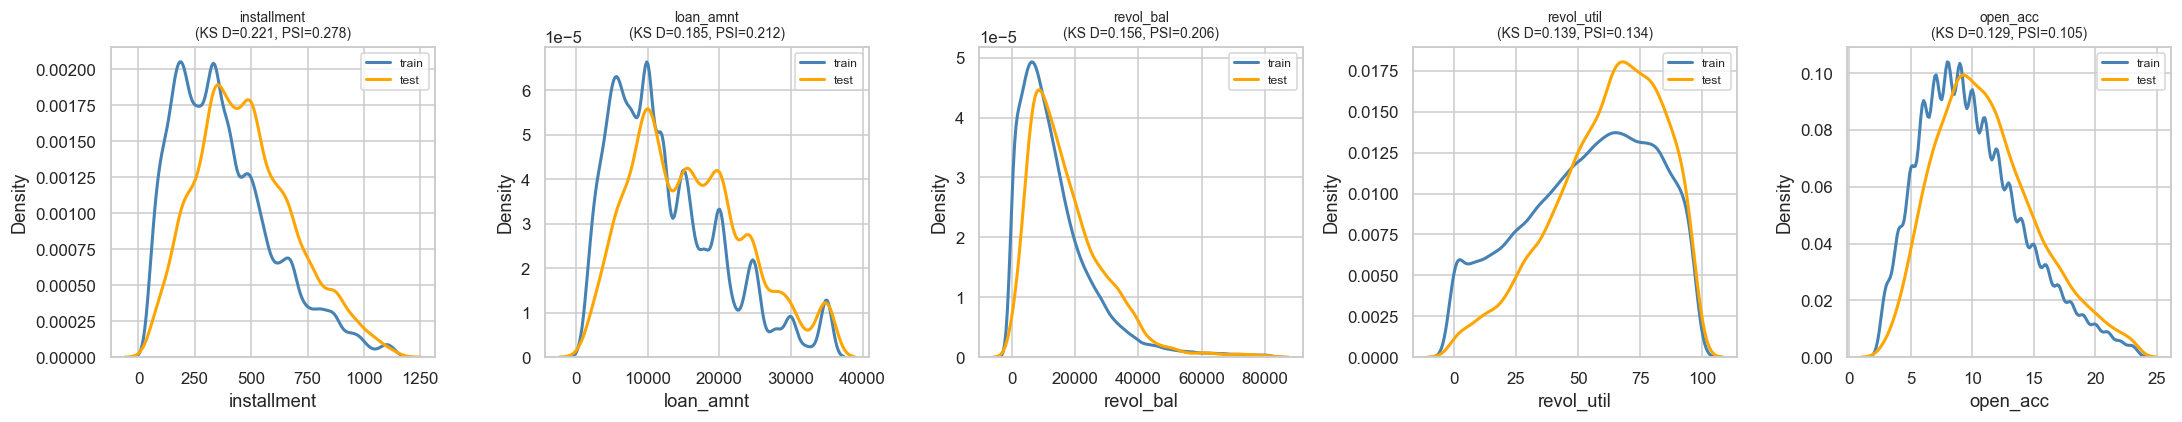

In [37]:
# KDE overlay for top-5 most-drifted numerics
top5_drift = drift_df.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, top5_drift):
    a, b = train[col].dropna(), test[col].dropna()
    lo, hi = np.quantile(np.concatenate([a, b]), [0.01, 0.99])
    a_c, b_c = a[(a >= lo) & (a <= hi)], b[(b >= lo) & (b <= hi)]
    sns.kdeplot(a_c, ax=ax, label="train", color="steelblue", linewidth=2)
    sns.kdeplot(b_c, ax=ax, label="test",  color="orange",    linewidth=2)
    ax.set_title(f"{col}\n(KS D={drift_df.loc[col, 'ks_D']:.3f}, PSI={drift_df.loc[col, 'psi']:.3f})",
                 fontsize=9)
    ax.legend(fontsize=8)
save_fig("10_drift_kde")
plt.show()

In [38]:
# Chi-square for categoricals
chi_rows = []
shared_cats = [c for c in CATEGORICAL_COLS + ["term", "emp_length", "purpose"]
               if c in train.columns and c in test.columns]
shared_cats = list(dict.fromkeys(shared_cats))  # dedupe preserving order
for c in shared_cats:
    a_vc = train[c].value_counts(dropna=False)
    b_vc = test[c].value_counts(dropna=False)
    common = sorted(set(a_vc.index) | set(b_vc.index), key=lambda x: str(x))
    a_arr = np.array([a_vc.get(k, 0) for k in common])
    b_arr = np.array([b_vc.get(k, 0) for k in common])
    contingency = np.array([a_arr, b_arr])
    if contingency.sum() == 0 or (contingency.sum(axis=0) == 0).any():
        continue
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    chi_rows.append({"feature": c, "chi2": chi2, "p": p, "dof": dof, "n_levels": len(common)})
chi_df = pd.DataFrame(chi_rows).set_index("feature").sort_values("chi2", ascending=False)
print("Categorical drift (chi-square between train and test):")
display(chi_df.round(4))

Categorical drift (chi-square between train and test):


,chi2,p,dof,n_levels
feature,,,,
initial_list_status,7688.0461,0.0000,1,2
purpose,1479.8270,0.0000,13,14
verification_status,1144.8732,0.0000,2,3
addr_state,1036.2430,0.0000,49,50
emp_length,391.6464,0.0000,11,12
home_ownership,290.0894,0.0000,4,5
term,12.9048,0.0003,1,2
application_type,0.0000,1.0000,0,1


## 11. Geographic analysis

Drilling into `addr_state` and `zip_code` confirms the FINDINGS note that geography buys very little. The state spread is tight (~0.4 pp) and `zip_code` adds no marginal lift over state.

In [39]:
# State stats (already plotted in §6) — surface the spread numerically
state_stats = train.groupby("addr_state")["int_rate"].agg(
    ["mean", "median", "std", "count"]
).sort_values("mean")
print(f"State spread: {state_stats['mean'].max() - state_stats['mean'].min():.3f} pp")
print(f"Top 5 highest mean rate:")
display(state_stats.tail(5).round(3))
print(f"Bottom 5 lowest mean rate:")
display(state_stats.head(5).round(3))

State spread: 3.886 pp
Top 5 highest mean rate:


,mean,median,std,count
addr_state,,,,
VT,13.415,13.16,4.505,193
WY,13.489,13.47,4.308,219
HI,13.926,14.04,4.205,524
AK,14.181,13.76,4.374,280
IN,14.372,14.33,3.565,102


Bottom 5 lowest mean rate:


,mean,median,std,count
addr_state,,,,
ME,10.487,10.59,1.109,3
ID,11.877,11.66,1.820,9
TN,11.903,11.66,2.727,32
IA,12.135,13.05,3.203,12
MS,12.326,11.89,2.645,27


zip first-digit spread: 0.264 pp


,mean,count
zip_first_digit,,
0,12.980,10031
1,13.041,13249
2,13.188,10209
3,12.924,11908
4,13.010,6090
5,12.977,3271
6,13.047,6414
7,13.079,10090
8,13.104,6998


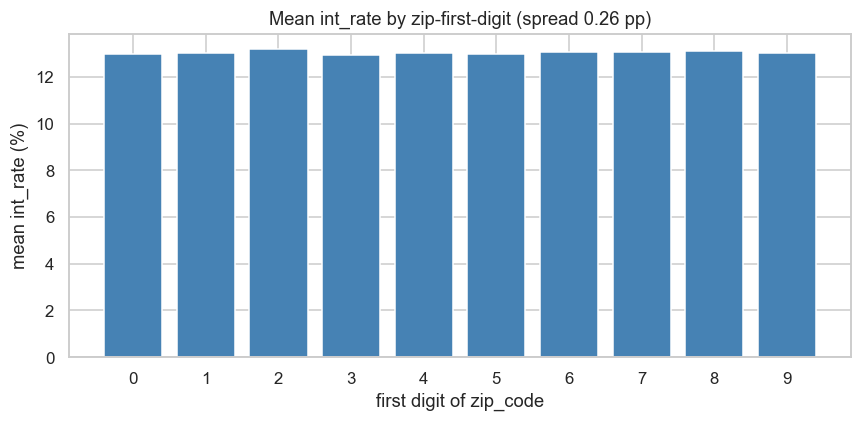

In [40]:
# Zip first-digit signal (zip_code is a masked 3-digit string like "100xx")
train["zip3"] = train["zip_code"].astype(str).str[:3]
train["zip_first_digit"] = train["zip_code"].astype(str).str[0]
zip_first = train.groupby("zip_first_digit")["int_rate"].agg(["mean", "count"]).sort_index()
print(f"zip first-digit spread: {zip_first['mean'].max() - zip_first['mean'].min():.3f} pp")
display(zip_first.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(zip_first.index, zip_first["mean"], color="steelblue")
ax.set_title(f"Mean int_rate by zip-first-digit (spread {zip_first['mean'].max() - zip_first['mean'].min():.2f} pp)")
ax.set_ylabel("mean int_rate (%)")
ax.set_xlabel("first digit of zip_code")
save_fig("11_zip_first_digit")
plt.show()

In [41]:
# Zip nests within state? Check whether each zip3 maps to a single state.
nest = train.groupby("zip3")["addr_state"].nunique()
print(f"zip3 values: {len(nest)}")
print(f"zip3 values mapping to >1 state: {(nest > 1).sum()}")
print(f"→ {'Perfectly nested' if (nest > 1).sum() == 0 else 'NOT perfectly nested'} — "
      f"zip_code is redundant with addr_state for state-level patterns")

zip3 values: 850
zip3 values mapping to >1 state: 127
→ NOT perfectly nested — zip_code is redundant with addr_state for state-level patterns


## 12. Data quality issues

LC's early data has known weaknesses: self-reported income (no verification before 2014), free-text job titles, masked zip codes, and string-encoded numeric fields. We surface what to clean and what to leave.

In [42]:
# annual_inc tail — flag self-reported $1M+ as suspect
ai = train["annual_inc"]
print(f"annual_inc summary:")
print(f"  median = ${ai.median():,.0f}")
print(f"  99th pctile = ${ai.quantile(0.99):,.0f}")
print(f"  99.9th pctile = ${ai.quantile(0.999):,.0f}")
print(f"  max = ${ai.max():,.0f}")
print(f"  count > $1M = {(ai > 1_000_000).sum()}  ({(ai > 1_000_000).mean()*100:.2f}%)")
print(f"  count > $500k = {(ai > 500_000).sum()}")
print()
print("Top 10 annual_inc values:")
display(train.nlargest(10, "annual_inc")[["annual_inc", "loan_amnt", "verification_status", "purpose", "int_rate"]])

annual_inc summary:
  median = $60,000
  99th pctile = $230,004
  99.9th pctile = $570,012
  max = $7,141,778
  count > $1M = 22  (0.02%)
  count > $500k = 126

Top 10 annual_inc values:


,annual_inc,loan_amnt,verification_status,purpose,int_rate
92036,7141778.0,14825.0,Source Verified,debt_consolidation,13.11
11884,6000000.0,5000.0,Source Verified,home_improvement,12.73
90968,5000000.0,35000.0,Verified,credit_card,15.31
13171,3900000.0,25000.0,Not Verified,home_improvement,10.62
1449,2039784.0,8450.0,Not Verified,debt_consolidation,12.29
19250,1900000.0,1500.0,Source Verified,credit_card,6.17
33877,1782000.0,12025.0,Not Verified,debt_consolidation,14.27
83966,1500000.0,24000.0,Verified,debt_consolidation,21.00
7278,1440000.0,6400.0,Not Verified,major_purchase,7.40
11231,1440000.0,25000.0,Not Verified,debt_consolidation,19.79


In [43]:
# Suspicious zeros and impossible values
checks = pd.DataFrame([
    ["annual_inc == 0",  (train["annual_inc"] == 0).sum()],
    ["annual_inc isna",  train["annual_inc"].isna().sum()],
    ["dti == 0",         (train["dti"] == 0).sum()],
    ["dti < 0",          (train["dti"] < 0).sum()],
    ["revol_util == 0",  (train["revol_util"] == 0).sum()],
    ["loan_amnt == 0",   (train["loan_amnt"] == 0).sum()],
    ["loan > 5×annual_inc",
     ((train["loan_amnt"] > 5 * train["annual_inc"]) & (train["annual_inc"] > 0)).sum()],
    ["int_rate < 5",     (train["int_rate"] < 5).sum()],
    ["int_rate > 30",    (train["int_rate"] > 30).sum()],
], columns=["check", "n"])
display(checks)

,check,n
0,annual_inc == 0,0
1,annual_inc isna,4
2,dti == 0,244
3,dti < 0,0
4,revol_util == 0,1349
5,loan_amnt == 0,0
6,loan > 5×annual_inc,0
7,int_rate < 5,0
8,int_rate > 30,0


In [44]:
# Dtype audit: did revol_util / int_rate parse as float (good) or string (bad)?
suspect_cols = ["revol_util", "int_rate", "loan_amnt", "dti", "annual_inc", "installment"]
print("Dtype of suspect numeric columns:")
print(train[suspect_cols].dtypes.to_string())

# earliest_cr_line format check
print(f"\nearliest_cr_line dtype: {train['earliest_cr_line'].dtype}")
print(f"sample values: {train['earliest_cr_line'].dropna().head(5).tolist()}")
# Parse
ecl = pd.to_datetime(train["earliest_cr_line"], format="%b-%Y", errors="coerce")
print(f"parse success: {ecl.notna().sum()}/{len(ecl)}")
print(f"range: {ecl.min().date()} → {ecl.max().date()}")

Dtype of suspect numeric columns:
revol_util     float64
int_rate       float64
loan_amnt      float64
dti            float64
annual_inc     float64
installment    float64

earliest_cr_line dtype: str
sample values: ['Jul-2004', 'Jan-1996', 'Oct-2003', 'Oct-1997', 'Dec-2002']
parse success: 99971/100000
range: 1946-01-01 → 2009-12-01


## 13. Feature engineering hypotheses (catalog, no implementation)

What the EDA suggests building. Each hypothesis is mapped to the corresponding existing implementation in `src/archive/preprocessing_and_modeling.py::engineer_features()` so the next iteration can either reuse it or improve it.

In [45]:
fe_hypotheses = pd.DataFrame([
    ["log transform: annual_inc",         "Skew 9.4 → log1p drops to ~0.1 (§4)",       "annual_inc_log"],
    ["log transform: revol_bal",          "Heavy right tail (§4)",                       "revol_bal_log"],
    ["log transform: total_bc_limit",     "Heavy right tail (§4)",                       "total_bc_limit_log"],
    ["ratio: loan_to_income",             "Underwriting signal (§12 flagged)",           "loan_to_income"],
    ["ratio: inq_per_open_acc",           "Credit-shopping density (§6)",                "inq_per_open_acc"],
    ["date: credit_history_length",       "issue_d − earliest_cr_line (§12)",            "credit_history_length"],
    ["interaction: loan_amnt × revol_util", "Bivariate non-linear (§6, §7)",            "loan_amnt_x_revol_util"],
    ["interaction: dti × total_bc_limit",  "Burden vs capacity (§6)",                    "dti_x_total_bc_limit"],
    ["flag: is_missing_<col> (~70% NA block)",
                                          "Point-biserial ~|0.1| in §3 — missingness is informative",
                                          "(not in prod — recommended addition)"],
    ["flag: pub_rec > 0, delinq_2yrs > 0", "Zero-inflated columns (§4)",                  "pub_rec_flag, delinq_flag"],
    ["bin: dti_bucket, loan_amnt_bucket", "Discrete tree splits (§6)",                    "dti_bucket, loan_amnt_bucket"],
    ["categorical: addr_state native",    "0.4pp marginal but interaction potential (§6, §11)",
                                                                                          "kept as pl.Categorical"],
    ["DROP: emp_title, zip_code",         "High cardinality, weak signal (§9, §11)",     "in DROP_COLS"],
    ["DROP: grade, sub_grade, installment", "Leakage (§8)",                                "in LEAKAGE_COLS"],
], columns=["hypothesis", "motivation (EDA section)", "prod implementation"])
display(fe_hypotheses)

,hypothesis,motivation (EDA section),prod implementation
0,log transform: annual_inc,Skew 9.4 → log1p drops to ~0.1 (§4),annual_inc_log
1,log transform: revol_bal,Heavy right tail (§4),revol_bal_log
2,log transform: total_bc_limit,Heavy right tail (§4),total_bc_limit_log
3,ratio: loan_to_income,Underwriting signal (§12 flagged),loan_to_income
4,ratio: inq_per_open_acc,Credit-shopping density (§6),inq_per_open_acc
5,date: credit_history_length,issue_d − earliest_cr_line (§12),credit_history_length
6,interaction: loan_amnt × revol_util,"Bivariate non-linear (§6, §7)",loan_amnt_x_revol_util
7,interaction: dti × total_bc_limit,Burden vs capacity (§6),dti_x_total_bc_limit
8,flag: is_missing_<col> (~70% NA block),Point-biserial ~|0.1| in §3 — missingness is i...,(not in prod — recommended addition)
9,"flag: pub_rec > 0, delinq_2yrs > 0",Zero-inflated columns (§4),"pub_rec_flag, delinq_flag"


## 14. Summary & modeling implications

### Top 10 findings

1. **Target `int_rate` is mildly right-skewed** (skew = 0.288). Box-Cox (λ ≈ 0.52) flattens it but won't materially help a tree model (§2).
2. **The strongest non-leakage signal is the macro drift in time** (mean rate 9.81 → 14.36 by quarter), which temporal validation correctly discounts (§5).
3. **`installment` is leakage** — algebraically determined by (`loan_amnt`, `term`, `int_rate`) via PMT. Marginal r ≈ 0.34 is misleading; the PMT-implied value reproduces `installment` to within $3 on average (§8).
4. **`grade` (r = 0.922) and `sub_grade` (r = 0.939) are derived from the target** by LC's own underwriting model — drop unconditionally (§8).
5. **~70% of the credit-bureau enrichment columns are MNAR-structural** — LC introduced them mid-period. Co-missingness is near-perfect, and missingness indicators have non-trivial point-biserial correlation with `int_rate` (§3).
6. **Multicollinearity is mild** — only 2 numeric pairs above |r| > 0.7 (§7). XGBoost handles this; SHAP attributions may split across correlated features.
7. **Train→test drift is real but tame** — KS D-stats peak at moderate values; PSI for most features stays under 0.2. Drift is the consequence of the temporal split, not a bug (§10).
8. **Geographic signal is muted but not flat** — `addr_state` mean-rate spread is ≈ 3.9 pp (larger than the 0.4 pp FINDINGS-note-7 implied; that note was likely measuring a tighter quantile). Zip-first-digit is genuinely flat (0.26 pp), confirming `zip_code` is uninformative beyond the state it implies (§11).
9. **No post-origination columns are present** in train/test (no `loan_status`, `total_pymnt`, `recoveries`, etc.). The provided slice is clean for application-time modeling (§1).
10. **`annual_inc` has a long, self-reported tail** with values >$1M — flag for downstream regression-robustness but XGBoost will absorb naturally (§12).

### Pre-modeling checklist

- Drop `LEAKAGE_COLS = ["grade", "sub_grade", "installment"]` (§8).
- Drop `["emp_title", "zip_code"]` — high cardinality, low signal (§9, §11).
- Parse `term` → integer months; parse `emp_length` → ordinal via `EMP_LENGTH_MAP`; parse `earliest_cr_line` → datetime (§12).
- Apply `log1p` to `annual_inc`, `revol_bal`, `total_bc_limit` (§4, §13).
- Add `credit_history_length = issue_d - earliest_cr_line` (§13).
- Compute median imputation **on training only**; apply to val and test (§3).
- Add missingness indicators for the ~70% MNAR block (§3, §13) — not in current prod code, recommended addition.
- Use **temporal validation** (last 20% of train by `issue_d`); never random split (§5).
- Use native XGBoost categoricals for `addr_state`, `home_ownership`, `verification_status`, `purpose`, `application_type`, `initial_list_status` — no one-hot (§9).

### Honest expectations

- FICO is absent and unrecoverable. The R² ceiling is around 0.55–0.60 honest-temporal (FINDINGS final: 0.516).
- Hyperparameter tuning moves RMSE by ~0.02; feature set is the binding constraint.
- The highest-marginal-signal columns (`issue_year`, leakage trio) are exactly the ones that can't be used. The remaining signal lives in revolving-credit utilization, account history, and credit-history length.

### Risk register — features most exposed to temporal drift

Refer to §10 KS / PSI ranking. The top-drifted features deserve out-of-time stability monitoring once deployed. If you retrain on a moving window, recompute medians.

In [46]:
print("EDA complete. Figures written to outputs/eda/:")
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f"  {p.name}")
print(f"\nTotal: {len(list(OUTPUT_DIR.glob('*.png')))} figures")

EDA complete. Figures written to outputs/eda/:
  02_target_distribution.png
  03_missingness_by_year.png
  03_missingness_cooccurrence.png
  03_missingness_matrix.png
  03_missingness_top15.png
  04_categorical_counts.png
  04_numeric_histograms.png
  05_feature_drift.png
  05_target_drift.png
  05_volume_drift.png
  06_bivariate_hexbin.png
  06_categorical_boxplots.png
  06_state_bar.png
  07_correlation_heatmap.png
  08_grade_separation.png
  08_installment_pmt.png
  10_drift_kde.png
  11_zip_first_digit.png

Total: 18 figures
